# Fashion Intelligence System: Data Audit and Preprocessing

**COSC2753 Machine Learning, Assignment 2 (2026B)**

## Executive Summary

- **Purpose.** Audit the 38,617 row training catalogue, resolve every data defect with recorded evidence, and export one audited manifest that Tasks 1 to 4 all read. No modelling choice is made here.
- **Parsing.** 21 rows spill into `Unnamed:` columns because unquoted commas split `productDisplayName`. The spill sits after the last labelled column, so no target is misaligned and the names are rejoined rather than repaired by hand.
- **Linkage.** 5 of 38,617 metadata rows have no image file. One of them is the only `Suits` record, so image models observe **124** article types against **125** in the metadata.
- **Duplicates.** SHA-256 hashing finds **636** byte identical groups covering **1,399** images. 616 groups agree on every label and are collapsed to one representative. **20** groups disagree and are resolved record by record in Section 3.2.2.
- **Imbalance.** `usage` is **76.9%** Casual, `gender` **54.2%** Men, `season` **49.6%** Summer, and `articleType` spans 6,780 images down to 1 across 124 classes. Accuracy alone is not a usable headline metric for any task.
- **Leakage.** `productDisplayName` states the gender for **95.0%** of rows and the article type for **62.9%**, but `styles_prediction.csv` supplies only `id` and the four targets. Every metadata column is therefore diagnostic only and no text or category field enters a model.
- **Transform.** 38,595 of 38,612 images are already 60x80. `standardize_image()` converts to RGB and pads to that modal size, so almost no image is resampled and none is cropped or distorted.
- **What is deliberately not done here.** No global complete case filter, no rare class merging, no oversampling, no normalisation constants, no split. Each is a task level choice and each is justified as such in Section 3.

Sections 1 to 3 build that manifest. Only the training data is analysed; the submission template is opened for its column names alone.

## How to Run the Notebook

### Where to put the data

Unzip `A2_Fashion.zip` and arrange it as below. This notebook lives in `notebooks/`, so `datasets/` sits one level up. If the data lives elsewhere, change the single `DATA_ROOT` line in the third code cell and nothing else.

```
<repository root>
├── notebooks/
│   └── 00_eda_and_preprocessing.ipynb
├── src/
│   └── preprocessing.py            standardize_image(), shared by all four task notebooks
├── datasets/
│   ├── train/
│   │   ├── styles_train.csv        one row per training product, id plus nine metadata fields
│   │   └── images_train/           one JPEG per training product, named <id>.jpg
│   └── test/
│       ├── styles_prediction.csv   submission template, id plus the four target columns
│       └── images_test/            unlabelled JPEGs named <id>.jpg
└── preprocessed_datasets/          created by Section 3.4, not part of the zip
```

This notebook reads `datasets/train/` for the audit and opens `datasets/test/styles_prediction.csv` for its column names only, which is the evidence behind the inference constraint in Section 2.5. It never reads a test image, and it never writes anything inside `datasets/`.

### Running it

- Install dependencies with `pip install -r requirements.txt` from the repository root.
- Restart the kernel, then Run All. The notebook is written to execute top to bottom in one pass.
- A fixed seed of 42 governs every sampled figure, so each grid shows the same items on every run.
- Two cells dominate the runtime. The image audit in Section 1.5 hashes and decodes every training file, and the class mean images in Section 2.3 decode them again. Expect a few minutes each on a laptop.
- Sections 3.2 to 3.4 depend on the hashes computed in Section 1.6, so the notebook cannot be run out of order.

### What it produces

One file, `preprocessed_datasets/train_manifest.csv`. The four task notebooks read that manifest and load their images from `datasets/train/images_train/`.

In [1]:
%matplotlib inline

# Core data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.colors import LogNorm

# File auditing, hashing, and image decoding
import csv
import hashlib
import math
import warnings
from collections import Counter
from io import BytesIO
from pathlib import Path
from PIL import Image, ImageOps

# Association testing between the categorical targets, Section 2.4
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

In [2]:
# Every setting reused across the notebook is defined once here, so a change to the seed
# or to a threshold cannot leave two sections silently disagreeing.

RANDOM_STATE = 42   # Fixed so every sampled figure reproduces exactly

TARGETS = ["articleType", "season", "gender", "usage"]

# The columns the brief declares for styles_train.csv, checked against the file in Section 1.1
REQUIRED_COLUMNS = {
    "id", "gender", "masterCategory", "subCategory", "articleType",
    "baseColour", "season", "year", "usage", "productDisplayName",
}

# Thresholds quoted in the markdown, named here so the text and the code cannot drift apart
CONFUSABILITY_MIN_SUPPORT = 30    # Minimum class support to earn a mean image, Section 2.3
MEAN_IMAGE_SIZE = (60, 80)        # Width, height of the class mean images, Section 2.3
IMAGE_PAD_RGB = (255, 255, 255)   # Catalogue background, used when padding in Section 3.1

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8b6fc0", "#e87ba4"]
MUTED = "#6b7280"

print("Seed:", RANDOM_STATE, "| Targets:", TARGETS)

Seed: 42 | Targets: ['articleType', 'season', 'gender', 'usage']


In [3]:
# One place decides where the data is. src/data_paths.py accepts the documented
# datasets/ layout, the FashionDataset folder the course archive unpacks to, a Colab
# mount, or $A2_DATA_ROOT -- so this notebook runs on a marker's machine without
# anyone editing a path constant. The layout is in "How to Run" above.
import sys

PROJECT_ROOT = Path.cwd().resolve()
while (PROJECT_ROOT != PROJECT_ROOT.parent
       and not (PROJECT_ROOT / "pyproject.toml").is_file()):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_paths

# Raw, not the manifest: this notebook is what builds the manifest, so reading it
# here would be circular.
TRAIN_CSV = data_paths.raw_train_table()
TRAIN_IMAGE_DIR = data_paths.train_images()

# Opened in Section 2.5 for its column names only. The inference constraint argued there
# rests on what this file supplies, so it is read rather than quoted from the brief.
PREDICTION_TEMPLATE = data_paths.test_template()

# Read in Section 3.6 for the test-set integrity check, read-only and never fitted to.
TEST_IMAGE_DIR = data_paths.test_images()

# The only file this notebook writes
OUTPUT_ROOT = PROJECT_ROOT / "preprocessed_datasets"
EXPORT_MANIFEST = OUTPUT_ROOT / "train_manifest.csv"

# Fail here with one readable message naming every missing input and every place
# that was searched, rather than three cells later with a bare FileNotFoundError.
data_paths.check()

print("Training table :", TRAIN_CSV)
print("Training images:", f"{len(list(TRAIN_IMAGE_DIR.glob('*.jpg'))):,} files in {TRAIN_IMAGE_DIR}")
print("Manifest will be written to:", EXPORT_MANIFEST.resolve())

Training images found: 38,612 files
Manifest will be written to: D:\Machine-Learning-Assignment-2\preprocessed_datasets\train_manifest.csv


## 1. Data Understanding and Integrity Audit

### 1.1 CSV Parsing and Schema Check

The CSV is audited for row width and pandas parsing before labels are used. This confirms whether malformed product names have shifted any target columns.

The goal is not to re-document CSV parsing generally, but to establish that every downstream count and label refers to the intended product record. The raw-width check and cleaned dataframe check provide that evidence.

In [4]:
# Read the file twice on purpose. csv.reader reports the true field count per line, which
# pandas hides once it has padded the short rows out to a rectangle. The comparison is what
# establishes that the extra fields are a text spill and not shifted labels.
with TRAIN_CSV.open("r", encoding="utf-8-sig", newline="") as stream:
    raw_field_counts = pd.Series(len(line) for line in csv.reader(stream))

print("Header fields declared:", raw_field_counts.iloc[0])
print("Field counts across data rows:", raw_field_counts.iloc[1:].value_counts().to_dict())

raw_df = pd.read_csv(TRAIN_CSV)

print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print("Absent required columns:", sorted(REQUIRED_COLUMNS - set(raw_df.columns)))
print("Unexpected columns:", sorted(set(raw_df.columns) - REQUIRED_COLUMNS))

summary = pd.DataFrame({
    "Data Type": raw_df.dtypes,
    "Non-null": raw_df.notna().sum(),
    "Missing": raw_df.isna().sum(),
    "Unique": raw_df.nunique(dropna=True),
})

display(summary)

Header fields declared: 12
Field counts across data rows: {12: 38617}
Raw shape: 38,617 rows x 12 columns
Absent required columns: []
Unexpected columns: ['Unnamed: 10', 'Unnamed: 11']


,Data Type,Non-null,Missing,Unique
id,int64,38617,0,38617
gender,str,38617,0,5
masterCategory,str,38617,0,7
subCategory,str,38617,0,41
articleType,str,38617,0,125
baseColour,str,38603,14,46
season,str,38597,20,4
year,int64,38617,0,12
usage,str,38545,72,8
productDisplayName,str,38610,7,27550


In [5]:
overflow_columns = [c for c in raw_df.columns if str(c).startswith("Unnamed:")]
overflow_mask = raw_df[overflow_columns].notna().any(axis=1)

print("Affected rows:", overflow_mask.sum())

display(
    raw_df.loc[
        overflow_mask,
        ["id", "productDisplayName", *overflow_columns],
    ]
)

Affected rows: 21


,id,productDisplayName,Unnamed: 10,Unnamed: 11
1320,3413,Myntra Men's Yes,its all about me White T-shirt,NaN
1325,3418,Myntra Men's Take my advice,I don't use it anyway Black T-shirt,NaN
1335,3428,Myntra Mens Be Reasonable,Do It My Way T-shirt,NaN
2689,4854,Newfeel Unisex White,Blue and Orange Casual Shoes,NaN
17899,23100,Turtle Men Formal Navy Blue Tie,Cufflink and Pocket Square Combo Set,NaN
17900,23101,Turtle Men Formal Pink Tie,Cufflink and Pocket Square Combo Set,NaN
17902,23103,Turtle Men Formal Black Tie,Cufflink and Pocket Square Combo Set,NaN
17906,23107,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17907,23108,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17908,23109,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN


#### What the Spill Does and Does Not Affect

Every one of the 38,617 data rows carries 12 fields, and so does the header: the ten named columns plus two blank ones, which is why pandas creates `Unnamed: 10` and `Unnamed: 11`. Only 21 rows put anything in them, where unquoted commas split `productDisplayName`.

The spill occurs only after the last real column, so target labels remain aligned. The affected name fragments can therefore be rejoined without manual label repair.

The affected fields are text fragments rather than additional attributes. Rejoining them preserves the original display name and avoids propagating truncated text into later diagnostics. Because the labels precede `productDisplayName`, no target needs to be inferred or corrected.

In [6]:
def repair_product_name(row):
    parts = []
    for column in ["productDisplayName", *overflow_columns]:
        value = row.get(column)
        if pd.notna(value) and str(value).strip():
            parts.append(str(value).strip())
    return ", ".join(parts) if parts else np.nan


metadata_df = raw_df.copy()
if overflow_columns:
    metadata_df.loc[overflow_mask, "productDisplayName"] = (
        metadata_df.loc[overflow_mask].apply(repair_product_name, axis=1)
    )
    metadata_df = metadata_df.drop(columns=overflow_columns)

print(f"Rows repaired: {int(overflow_mask.sum()):,}")
print(f"Cleaned shape: {metadata_df.shape[0]:,} rows x {metadata_df.shape[1]} columns")
assert len(metadata_df) == len(raw_df)
assert not [c for c in metadata_df.columns if str(c).startswith("Unnamed:")]

metadata_df.loc[
    overflow_mask,
    ["id", "productDisplayName"],
]

Rows repaired: 21
Cleaned shape: 38,617 rows x 10 columns


,id,productDisplayName
1320,3413,"Myntra Men's Yes, its all about me White T-shirt"
1325,3418,"Myntra Men's Take my advice, I don't use it anyway Black T-shirt"
1335,3428,"Myntra Mens Be Reasonable, Do It My Way T-shirt"
2689,4854,"Newfeel Unisex White, Blue and Orange Casual Shoes"
17899,23100,"Turtle Men Formal Navy Blue Tie, Cufflink and Pocket Square Combo Set"
17900,23101,"Turtle Men Formal Pink Tie, Cufflink and Pocket Square Combo Set"
17902,23103,"Turtle Men Formal Black Tie, Cufflink and Pocket Square Combo Set"
17906,23107,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"
17907,23108,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"
17908,23109,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"


The 21 names are reconstructed and the two surplus columns dropped. The row count stays at 38,617 and no `Unnamed:` column survives, which the assertions in the cell above confirm rather than assume.

### 1.2 Identifier Validity

`id` is the key linking metadata, image files, and audit results; its validity is checked before any merge.

In [7]:
numeric_ids = pd.to_numeric(metadata_df["id"], errors="coerce")
id_audit = pd.Series({
    "rows": len(metadata_df),
    "missing ids": int(metadata_df["id"].isna().sum()),
    "non-numeric ids": int(numeric_ids.isna().sum() - metadata_df["id"].isna().sum()),
    "non-positive ids": int((numeric_ids.dropna() <= 0).sum()),
    "unique ids": int(metadata_df["id"].nunique(dropna=True)),
    "duplicate id rows": int(metadata_df["id"].duplicated(keep=False).sum()),
    "exact duplicate rows": int(metadata_df.duplicated().sum()),
    "minimum id": int(numeric_ids.min()),
    "maximum id": int(numeric_ids.max()),
}, name="value")
display(id_audit.to_frame())

assert numeric_ids.notna().all() and (numeric_ids > 0).all()
assert metadata_df["id"].is_unique
metadata_df["id"] = numeric_ids.astype(int)

,value
rows,38617
missing ids,0
non-numeric ids,0
non-positive ids,0
unique ids,38617
duplicate id rows,0
exact duplicate rows,0
minimum id,1163
maximum id,51999


#### Why id Is Safe to Join On

All 38,617 IDs are numeric, positive, and unique, with no exact duplicate metadata rows. One-to-one joins on `id` cannot change the row count.

IDs range from 1,163 to 51,999 and are sparse catalogue keys, not meaningful numeric features. They are used only for linkage.

### 1.3 Label Availability per Task

Label availability is measured per task rather than through one global complete-case filter.

In [8]:
missing_table = pd.DataFrame({
    "Missing": metadata_df.isna().sum(),
    "Missing %": metadata_df.isna().mean().mul(100),
}).query("Missing > 0").sort_values("Missing", ascending=False)

availability_specs = {
    "Task 1 - articleType": ["articleType"],
    "Task 2 - season": ["season"],
    "Task 3a - gender": ["gender"],
    "Task 3b - usage": ["usage"],
    "Task 3 - both labels": ["gender", "usage"],
    "All four targets": TARGETS,
}
task_availability = pd.DataFrame(
    [
        [task, ", ".join(cols), int(metadata_df[cols].notna().all(axis=1).sum()),
         metadata_df[cols].notna().all(axis=1).mean() * 100]
        for task, cols in availability_specs.items()
    ],
    columns=["Task", "Required target(s)", "Labelled rows", "Availability %"],
)

display(missing_table.style.format({"Missing %": "{:.3f}%"}))
display(task_availability.style.format({"Availability %": "{:.3f}%"}))

,Missing,Missing %
usage,72,0.186%
season,20,0.052%
baseColour,14,0.036%
productDisplayName,7,0.018%


,Task,Required target(s),Labelled rows,Availability %
0,Task 1 - articleType,articleType,38617,100.000%
1,Task 2 - season,season,38597,99.948%
2,Task 3a - gender,gender,38617,100.000%
3,Task 3b - usage,usage,38545,99.814%
4,Task 3 - both labels,"gender, usage",38545,99.814%
5,All four targets,"articleType, season, gender, usage",38525,99.762%


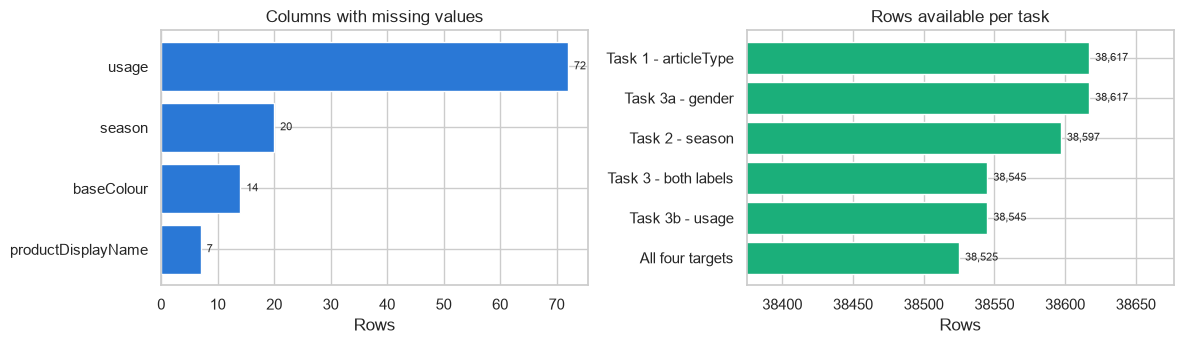

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_missing = missing_table.sort_values("Missing")
axes[0].barh(plot_missing.index, plot_missing["Missing"], color=PALETTE[0])
axes[0].set(title="Columns with missing values", xlabel="Rows")
for y, value in enumerate(plot_missing["Missing"]):
    axes[0].text(value, y, f"  {value:,}", va="center", fontsize=8)

available = task_availability.sort_values("Labelled rows")
axes[1].barh(available["Task"], available["Labelled rows"], color=PALETTE[2])
axes[1].set(title="Rows available per task", xlabel="Rows",
            xlim=(available["Labelled rows"].min() - 150, len(metadata_df) + 60))
for y, value in enumerate(available["Labelled rows"]):
    axes[1].text(value, y, f"  {value:,}", va="center", fontsize=8)
plt.tight_layout();
plt.show();

#### Why Availability Is Measured per Task

`articleType` and `gender` are complete across all 38,617 rows. `season` is missing on 20 rows, `usage` on 72, `baseColour` on 14, and `productDisplayName` on 7.

At metadata level, Task 1 and Task 3a have 38,617 usable rows, Task 2 has 38,597, Task 3b has 38,545, and only 38,525 rows carry all four labels. A single complete case filter would therefore discard 92 rows that are fully usable for the task being run, so no such filter is applied anywhere in this notebook. Missing labels are kept as `NaN` and each task section selects on its own label column, which is the arrangement Section 3.3 confirms and the exported dataset preserves.

These counts are label missingness only, measured before image availability. The task specific denominator matters because a model evaluated on Task 2 or Task 3b does not see the same candidate rows as one evaluated on Task 1, even before the conflict decisions in Section 3.2.2 remove further records.

### 1.4 Metadata and Image Linkage

Metadata rows and image files are matched by filename stem in both directions.

In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

manifest_rows = []
non_image_files = []
for path in sorted(TRAIN_IMAGE_DIR.iterdir(), key=lambda p: p.name.lower()):
    if not path.is_file():
        continue
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        non_image_files.append(path.name)
        continue
    try:
        image_id = int(path.stem)
    except ValueError:
        continue
    manifest_rows.append({"id": image_id, "filename": path.name, "path": str(path.resolve())})

image_manifest = pd.DataFrame(manifest_rows)
metadata_ids = set(metadata_df["id"])
image_ids = set(image_manifest["id"])

linkage_summary = pd.DataFrame([
    ["Metadata rows", len(metadata_df)],
    ["Image files found", len(image_manifest)],
    ["Metadata rows with an image", len(metadata_ids & image_ids)],
    ["Metadata rows without an image", len(metadata_ids - image_ids)],
    ["Images without metadata", len(image_ids - metadata_ids)],
    ["Duplicate image-derived ids", int(image_manifest["id"].duplicated().sum())],
    ["Non-image files ignored", len(non_image_files)],
], columns=["Linkage measure", "Count"])
display(linkage_summary)

print("Metadata ids without an image:", sorted(metadata_ids - image_ids)[:20])

,Linkage measure,Count
0,Metadata rows,38617
1,Image files found,38612
2,Metadata rows with an image,38612
3,Metadata rows without an image,5
4,Images without metadata,0
5,Duplicate image-derived ids,0
6,Non-image files ignored,1


Metadata ids without an image: [12347, 39401, 39403, 39410, 39425]


#### What the Five Missing Files Cost

38,612 of 38,617 rows have a matching image; no image file lacks metadata. Missing files are IDs `12347`, `39401`, `39403`, `39410`, and `39425`.

ID `12347` is the only `Suits` record, so image-based tasks observe 124 article types while metadata contains 125. The five rows are excluded from image modelling and reported explicitly; replacement images are out of scope.

The missing-image audit also prevents a misleading statement that the 125 metadata classes are all available to an image model. Keeping the raw metadata count alongside the image-observed count makes the class loss visible in later reports.

### 1.5 Image File Integrity Audit

The image audit records decodability, dimensions, colour mode, and SHA-256 digest, which are the properties needed for modelling and for duplicate control.

In [11]:
audit_rows = []
for row in image_manifest.itertuples(index=False):
    path = Path(row.path)
    record = {
        "id": int(row.id), "filename": row.filename, "path": str(path),
        "file_bytes": path.stat().st_size, "readable": False, "format": None,
        "width": np.nan, "height": np.nan, "aspect_ratio": np.nan,
        "mode": None, "is_grayscale": False, "sha256": None, "error": None,
    }
    try:
        raw_bytes = path.read_bytes()
        record["sha256"] = hashlib.sha256(raw_bytes).hexdigest()
        with Image.open(BytesIO(raw_bytes)) as image:
            image.verify()
        with Image.open(BytesIO(raw_bytes)) as image:
            detected_format = image.format
            image = ImageOps.exif_transpose(image)
            record.update({
                "readable": True, "format": detected_format,
                "width": image.width, "height": image.height,
                "aspect_ratio": image.width / image.height,
                "mode": image.mode, "is_grayscale": image.mode in {"1", "L", "I", "F"},
            })
    except Exception as error:
        record["error"] = f"{type(error).__name__}: {error}"
    audit_rows.append(record)

image_audit_df = pd.DataFrame(audit_rows)
readable_audit = image_audit_df.loc[image_audit_df["readable"]].copy()

display(pd.DataFrame([
    ["Linked image files", len(image_audit_df)],
    ["Readable", int(image_audit_df["readable"].sum())],
    ["Unreadable / corrupt", int((~image_audit_df["readable"]).sum())],
    ["Empty files", int(image_audit_df["file_bytes"].eq(0).sum())],
], columns=["Integrity measure", "Images"]))

,Integrity measure,Images
0,Linked image files,38612
1,Readable,38612
2,Unreadable / corrupt,0
3,Empty files,0


#### Image Figure Helper

Every image figure below is drawn through the same two functions.

- `sample_paths` takes a fixed number of rows at a fixed seed, so a figure shows the same items on every run and a claim made about one grid can be checked against it later.
- `show_image_grid` draws one grid with optional row labels, so grids from different sections are directly comparable.
- `path_by_id` is the one file location lookup every figure and verification cell shares, rather than each rebuilding its own.

They are defined once, immediately before the first figure that uses them, and are called again in Sections 1.6, 2.1, 2.2 and 3.1.

In [12]:
# One shared lookup from catalogue id to file location, used by every figure below and
# by the transform verification in Section 3.1.
path_by_id = readable_audit.set_index("id")["path"]


def sample_paths(frame, n, seed_offset=0):
    """Take up to n rows deterministically from a frame holding id and path columns.

    Args:
        frame: rows to sample from.
        n: maximum number of rows to return.
        seed_offset: added to RANDOM_STATE so different figures show different items
            while each individual figure stays reproducible.

    Returns:
        A list of namedtuples, empty if the frame is empty.
    """
    if len(frame) == 0:
        return []
    picked = frame.sample(n=min(n, len(frame)), random_state=RANDOM_STATE + seed_offset)
    return list(picked.itertuples(index=False))


def show_image_grid(rows, title=None, row_labels=None, scale=1.5):
    """Draw one grid of images.

    Args:
        rows: list of rows, each a list of (path, caption) pairs. Rows may differ in
            length; the shorter ones leave their trailing panels blank.
        title: figure title.
        row_labels: one label per row, drawn to the left of the first panel.
        scale: panel size multiplier.
    """
    ncols = max(len(row) for row in rows)
    fig, axes = plt.subplots(
        len(rows), ncols,
        figsize=(scale * ncols, scale * 1.5 * len(rows) + 0.5),
        squeeze=False,
    )
    for row_index, row in enumerate(rows):
        for column_index in range(ncols):
            ax = axes[row_index][column_index]
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column_index < len(row):
                path, caption = row[column_index]
                with Image.open(path) as image:
                    ax.imshow(ImageOps.exif_transpose(image).convert("RGB"))
                if caption:
                    ax.set_title(caption, fontsize=7)

        if row_labels:
            axes[row_index][0].set_ylabel(
                row_labels[row_index], fontsize=8, rotation=0, ha="right", va="center"
            )

    if title:
        fig.suptitle(title, y=1.0, fontsize=11)

    plt.tight_layout()
    plt.show()

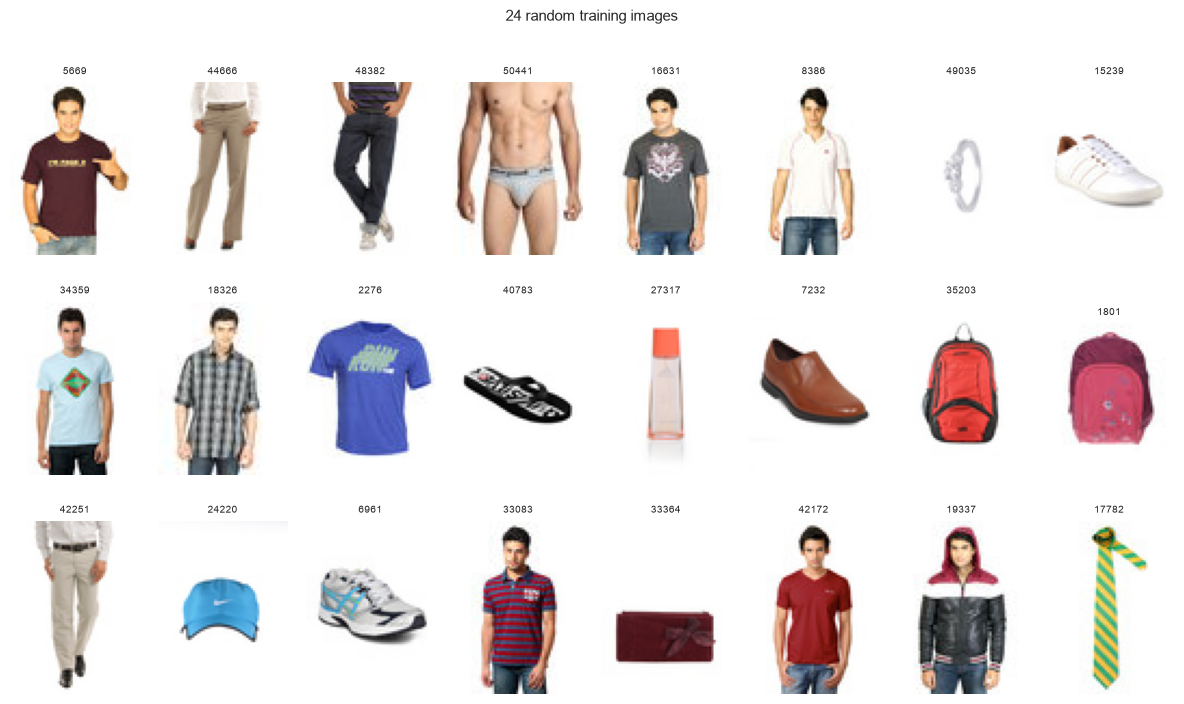

In [13]:
# What are we actually looking at? A plain sample first, before any statistics.
random_sample = sample_paths(readable_audit, 24)
show_image_grid(
    [[(r.path, str(r.id)) for r in random_sample[i:i + 8]] for i in range(0, len(random_sample), 8)],
    title="24 random training images",
)

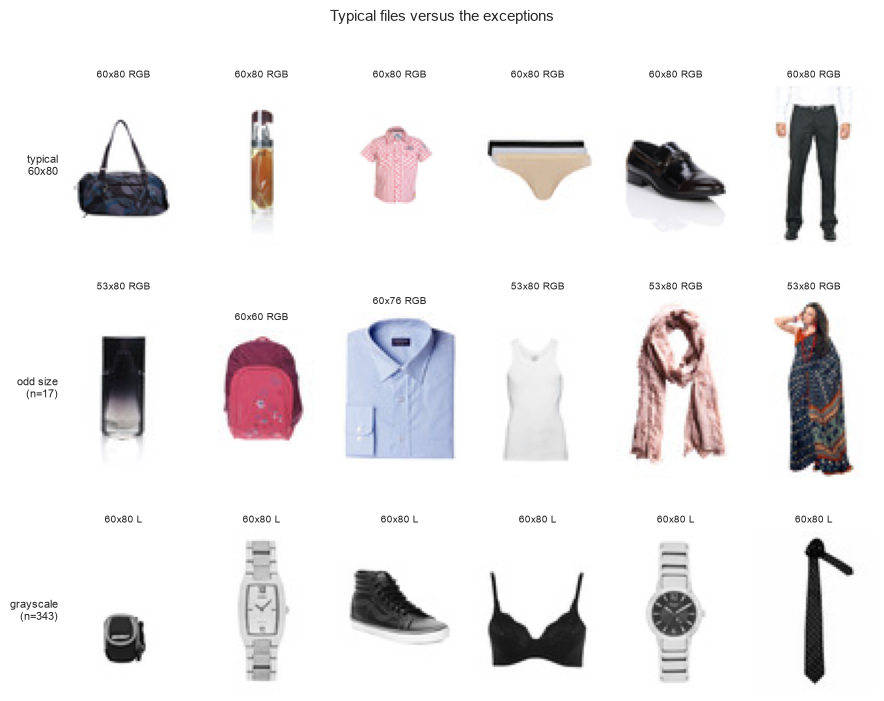

In [14]:
# Now the files that are NOT typical, since those are what the transform has to survive.
modal_dimensions = readable_audit.groupby(["width", "height"]).size().idxmax()
odd_sized = readable_audit.loc[
    (readable_audit["width"] != modal_dimensions[0]) | (readable_audit["height"] != modal_dimensions[1])
]
grayscale_files = readable_audit.loc[readable_audit["is_grayscale"]]

typical_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(
    readable_audit.loc[readable_audit["width"].eq(modal_dimensions[0])
                       & readable_audit["height"].eq(modal_dimensions[1])
                       & ~readable_audit["is_grayscale"]], 6, seed_offset=1)]
odd_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(odd_sized, 6, seed_offset=2)]
gray_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(grayscale_files, 6, seed_offset=3)]

show_image_grid(
    [row for row in [typical_row, odd_row, gray_row] if row],
    row_labels=[label for label, row in
                [(f"typical\n{modal_dimensions[0]}x{modal_dimensions[1]}", typical_row),
                 (f"odd size\n(n={len(odd_sized)})", odd_row),
                 (f"grayscale\n(n={len(grayscale_files)})", gray_row)] if row],
    title="Typical files versus the exceptions",
)

#### What the File Audit Rules Out

All 38,612 linked files decode successfully and are JPEGs; there are no corrupt or zero-byte files. The five absent images are therefore the only image-side row loss.

The sample grids show a consistent studio catalogue: centred products, white backgrounds, and similar framing. Odd-sized and grayscale files are valid products, so the transform handles them rather than dropping rows. Pixel statistics are deferred because normalisation must be fitted on training rows after a split.

The technical consistency supports a simple common transform rather than separate pipelines for multiple image formats. It also means that any later model failure is unlikely to be explained by unreadable files or a broad mix of photographic conventions. The white studio background is common across classes, so it should not be treated as a class-specific visual signal.

The observed file properties also constrain the interpretation of later preprocessing experiments. A model evaluated at a larger tensor size is seeing an interpolation of small catalogue images, not new visual detail. The audit therefore establishes a meaningful native-resolution baseline against which larger backbones or augmentation policies can be assessed.

### 1.6 Exact Duplicate Detection

Exact duplicates are identified from SHA-256 file hashes to control split leakage and expose conflicting supervision.

In [15]:
hash_counts = readable_audit["sha256"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]
duplicate_members = readable_audit.loc[
    readable_audit["sha256"].isin(duplicate_hashes.index), ["id", "sha256"]
].merge(metadata_df[["id", *TARGETS]], on="id", how="left")

display(pd.Series({
    "readable images": len(readable_audit),
    "unique SHA-256 hashes": readable_audit["sha256"].nunique(),
    "duplicate groups": len(duplicate_hashes),
    "images in duplicate groups": int(duplicate_hashes.sum()),
    "largest duplicate group": int(duplicate_hashes.max()) if len(duplicate_hashes) else 1,
}, name="value").to_frame())

if len(duplicate_members):
    conflicts = duplicate_members.groupby("sha256")[TARGETS].nunique().gt(1).sum()
    display(conflicts.rename("groups with conflicting labels").to_frame())

,value
readable images,38612
unique SHA-256 hashes,37849
duplicate groups,636
images in duplicate groups,1399
largest duplicate group,4


,groups with conflicting labels
articleType,7
season,8
gender,7
usage,3


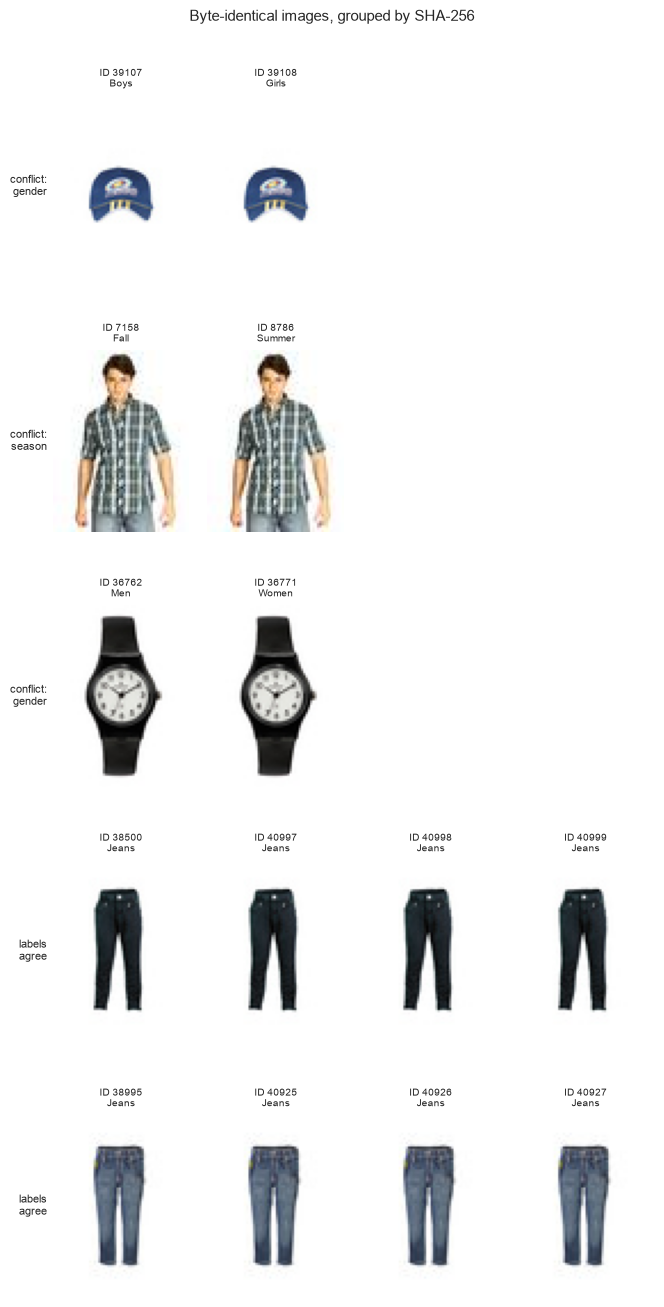

In [16]:
# Show duplicate groups as images, conflicting-label groups first - this is the label-noise evidence.
group_labels = duplicate_members.groupby("sha256")[TARGETS].nunique()
conflicting_hashes = group_labels.loc[group_labels.gt(1).any(axis=1)].index.tolist()
clean_hashes = [h for h in duplicate_hashes.index if h not in conflicting_hashes]

grid_rows, grid_labels = [], []
for digest in (conflicting_hashes[:3] + clean_hashes[:2]):
    members = duplicate_members.loc[duplicate_members["sha256"].eq(digest)]
    disagreeing = [t for t in TARGETS if members[t].nunique(dropna=True) > 1]
    row = []
    for member in members.itertuples(index=False):
        caption = f"ID {member.id}"
        for target in (disagreeing or ["articleType"]):
            caption += f"\n{getattr(member, target)}"
        row.append((path_by_id.loc[member.id], caption))
    grid_rows.append(row)
    grid_labels.append(("conflict:\n" + ", ".join(disagreeing)) if disagreeing else "labels\nagree")

if grid_rows:
    show_image_grid(grid_rows, row_labels=grid_labels, scale=1.7,
                    title="Byte-identical images, grouped by SHA-256")

#### Two Risks the Duplicates Carry

There are 636 duplicate groups covering 1,399 images; the largest group contains four copies. Conflicting labels occur in 7 groups for `articleType`, 8 for `season`, 7 for `gender`, and 3 for `usage`.

Raw rows and JPEGs remain unchanged. The digest is carried into `model_ready` as `group_id`, so a task split can keep byte identical images on one side and the exported CSV carries the column for that purpose. Section 3.2 applies its decisions once, to the shared table, and every row not named in those decisions stays available to every task.

Hashes detect exact copies only. Alternate views, colourways, and reshoots may still cross a split; perceptual hashing is a stated limitation rather than part of this preprocessing.

**Duplicate-group risks.**

- **Leakage:** splitting a group lets validation reward memorising training pixels.
- **Contradictory supervision:** conflicting labels teach different answers for the same image.
- **Control:** `group_id` prevents split leakage; §3.2 applies only the documented label decisions.

### 1.7 Assembling the Shared Table

The audited metadata and image manifest are combined into the shared table used by all task sections.

In [17]:
manifest_link = image_manifest[["id", "filename", "path"]]
audit_flags = image_audit_df[["id", "readable", "sha256"]]

analysis_df = (
    metadata_df
    .merge(manifest_link, on="id", how="left")
    .merge(audit_flags, on="id", how="left")
)

model_ready = (
    analysis_df.loc[analysis_df["readable"].eq(True)]
    .drop(columns="readable")
    .rename(columns={"sha256": "group_id"})
    .reset_index(drop=True)
)

population_table = pd.DataFrame([
    ["Cleaned metadata rows", len(analysis_df)],
    ["Usable images (model_ready)", len(model_ready)],
    ["Task 1 - articleType", int(model_ready["articleType"].notna().sum())],
    ["Task 2 - season", int(model_ready["season"].notna().sum())],
    ["Task 3a - gender", int(model_ready["gender"].notna().sum())],
    ["Task 3b - usage", int(model_ready["usage"].notna().sum())],
    ["Task 4 - retrieval pool", len(model_ready)],
], columns=["Population", "Rows"])

display(population_table)

,Population,Rows
0,Cleaned metadata rows,38617
1,Usable images (model_ready),38612
2,Task 1 - articleType,38612
3,Task 2 - season,38592
4,Task 3a - gender,38612
5,Task 3b - usage,38540
6,Task 4 - retrieval pool,38612


#### Reconciling the Row Counts

`model_ready` reconciles to 38,617 cleaned metadata rows in and 38,612 image-usable rows out. The five row difference is exactly the missing-image set.

After image filtering, Task 1 and Task 3a have 38,612 rows, Task 2 has 38,592, Task 3b has 38,540, and Task 4 uses all 38,612 rows as its retrieval pool. Metadata columns, labels, filenames, paths, and `group_id` remain available for downstream filtering.

The table is intentionally broad enough for both classification and retrieval: classification tasks select their valid labels, while retrieval needs all readable image records. No global row drop is applied after the audit, which keeps this shared object reusable across the assignment.

## 2. Label Structure and Task Difficulty

### 2.1 Target Distributions

This section assesses support, imbalance, visual ambiguity, and which information is available at inference.

,Target,Labelled images,Classes,Largest class,Largest support,Largest share %,Smallest support
0,articleType,38612,124,Tshirts,6780,17.6%,1
1,season,38592,4,Summer,19135,49.6%,1566
2,gender,38612,5,Men,20913,54.2%,645
3,usage,38540,8,Casual,29636,76.9%,1


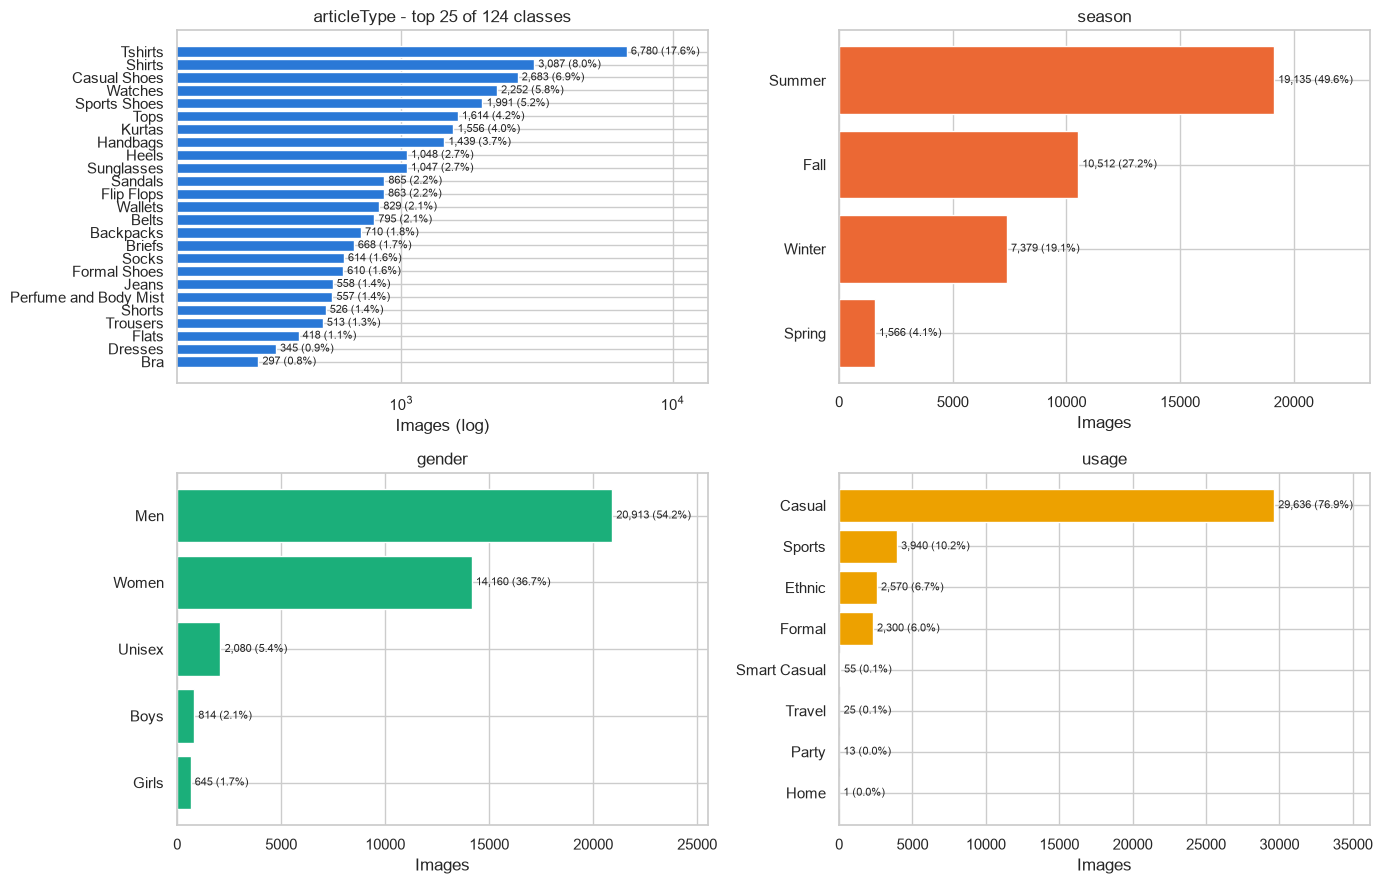

In [18]:
target_counts = {t: model_ready.loc[model_ready[t].notna(), t].value_counts() for t in TARGETS}

target_summary = pd.DataFrame([
    {
        "Target": t,
        "Labelled images": int(counts.sum()),
        "Classes": len(counts),
        "Largest class": counts.index[0],
        "Largest support": int(counts.iloc[0]),
        "Largest share %": counts.iloc[0] / counts.sum() * 100,
        "Smallest support": int(counts.iloc[-1]),
    }
    for t, counts in target_counts.items()
])
display(target_summary.style.format({"Largest share %": "{:.1f}%"}))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, target, color in zip(axes.flat, TARGETS, PALETTE[:4]):
    counts = target_counts[target]
    shown = (counts.head(25) if target == "articleType" else counts).sort_values()
    bars = ax.barh(shown.index, shown.values, color=color)
    total = counts.sum()
    labels = [f"{value:,} ({value / total:.1%})" for value in shown.values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
    if target == "articleType":
        ax.set_xscale("log")
        ax.set(title=f"articleType - top 25 of {len(counts)} classes", xlabel="Images (log)")
    else:
        ax.set(title=target, xlabel="Images")
    ax.set_ylabel("")
    ax.margins(x=0.22)  # leave room for count-and-percentage labels
plt.tight_layout(); plt.show()

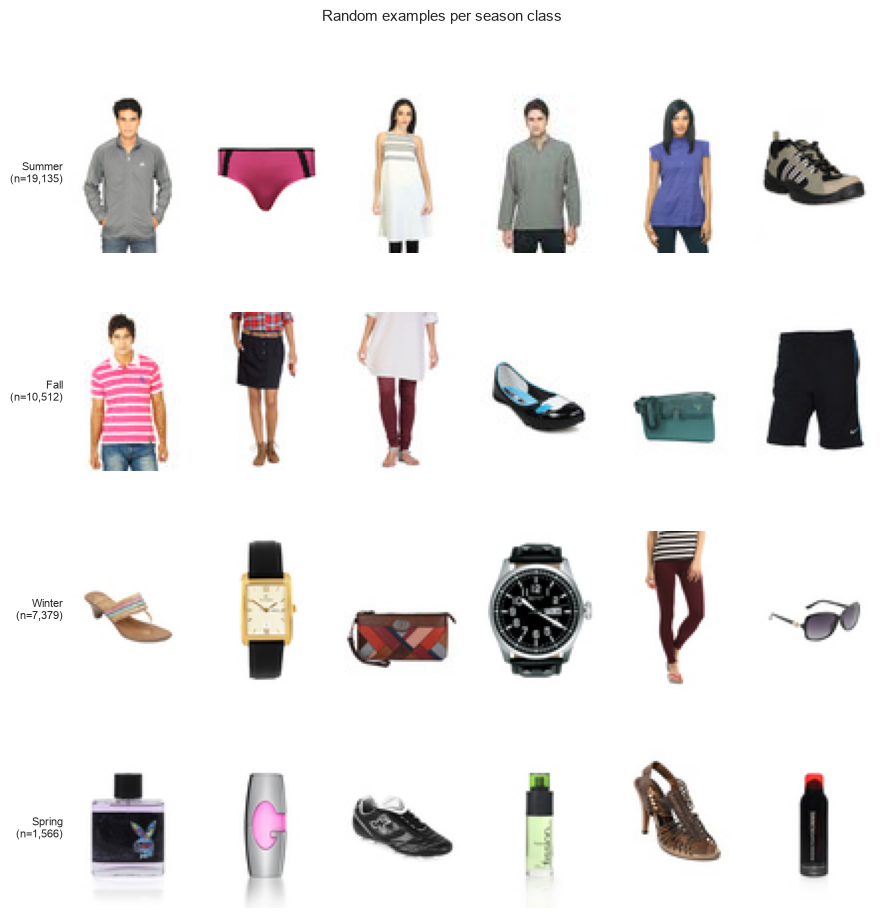

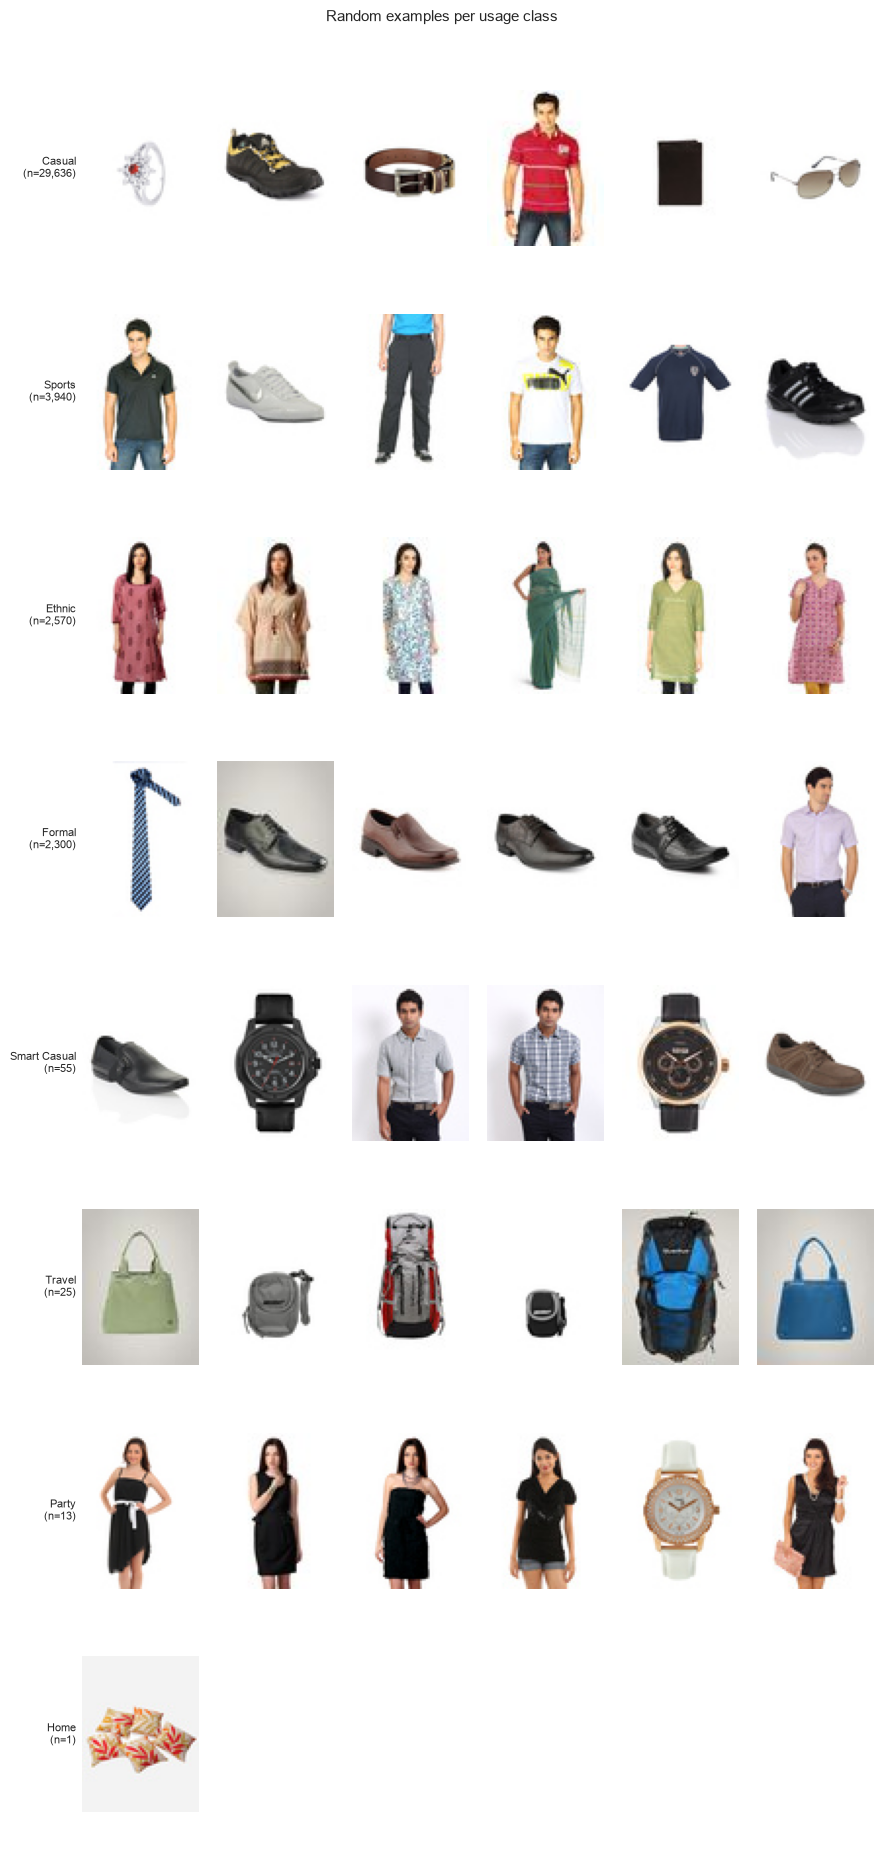

In [19]:
# Same number of examples per class. The offset comes from the position in the class list
# rather than from hash(label), because Python salts string hashing per process and the
# figure would then show different items on every kernel restart.
for target in ["season", "usage"]:
    rows, labels = [], []
    for offset, label in enumerate(target_counts[target].index):
        members = model_ready.loc[model_ready[target].eq(label), ["id", "path"]]
        picked = sample_paths(members, 6, seed_offset=offset)
        if picked:
            rows.append([(r.path, "") for r in picked])
            labels.append(f"{label}\n(n={target_counts[target][label]:,})")
    show_image_grid(rows, row_labels=labels, title=f"Random examples per {target} class")

#### What the Imbalance Means for Evaluation

The targets have different class structures:

- `articleType`: 124 classes; Tshirts has 6,780 images (17.6%), while the smallest class has one image.
- `season`: 4 classes; Summer has 19,135 images (49.6%).
- `gender`: 5 classes; Men has 20,913 images (54.2%).
- `usage`: 8 classes; Casual has 29,636 of 38,540 images (76.9%).

Accuracy alone is misleading, particularly for `usage`; headline results should include macro-averaged metrics. The image grids also suggest that season is a weakly visual merchandising label, so Task 2 may be difficult despite its small label space.

**Implications for evaluation.**

- The majority baseline is especially deceptive for `usage`.
- `articleType` combines a large label space with a severe long tail.
- `season` and `gender` may depend on weak or indirect visual cues.
- Each task should use an appropriate baseline and class-aware metrics.

The imbalance is not identical across tasks, so a single score cannot summarize the dataset's difficulty. Task reports should include the majority baseline, macro score, and selected per-class behaviour where the tail or semantically weak labels materially affect the conclusion.

### 2.2 Class Support and the Long Tail

Class support determines whether a target can be learned and evaluated reliably.

,Target,Classes,Max/min ratio,Median support,Singleton classes,Classes < 5,Classes < 10,Top-class share %
0,articleType,124,"6,780.0",43.5,6,21,32,17.6%
1,season,4,12.2,"8,945.5",0,0,0,49.6%
2,gender,5,32.4,"2,080.0",0,0,0,54.2%
3,usage,8,"29,636.0","1,177.5",1,1,1,76.9%


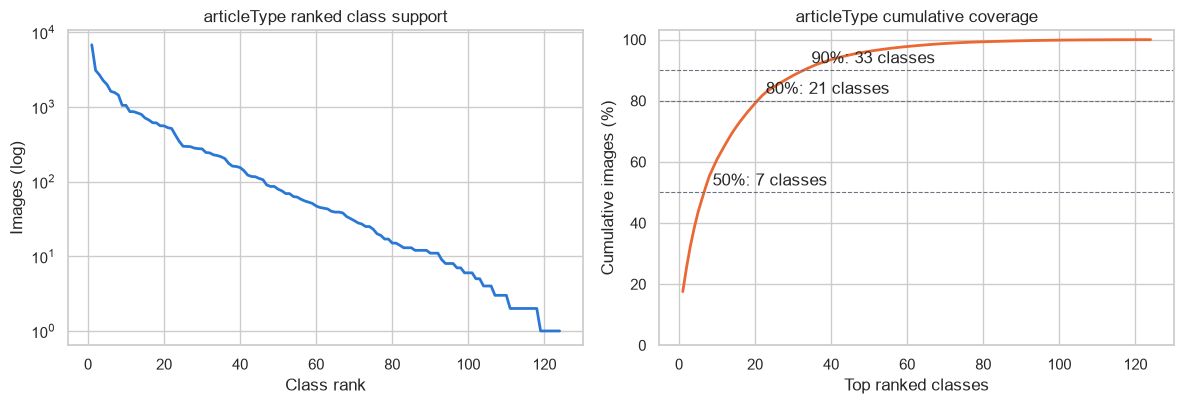

Classes needed for 50/80/90% of images: {50: 7, 80: 21, 90: 33}

Rare articleType classes (< 5 images):
{'Compact': 4, 'Lip Plumper': 4, 'Highlighter and Blush': 4, 'Hat': 3, 'Shrug': 3, 'Tablet Sleeve': 3, 'Trolley Bag': 3, 'Lehenga Choli': 2, 'Key chain': 2, 'Robe': 2, 'Shapewear': 2, 'Concealer': 2, 'Baby Dolls': 2, 'Rain Jacket': 2, 'Rain Trousers': 2, 'Shoe Laces': 1, 'Ties and Cufflinks': 1, 'Cushion Covers': 1, 'Body Wash and Scrub': 1, 'Ipad': 1, 'Lounge Tshirts': 1}


In [20]:
imbalance_table = pd.DataFrame([
    {
        "Target": t,
        "Classes": len(counts),
        "Max/min ratio": counts.max() / counts.min(),
        "Median support": counts.median(),
        "Singleton classes": int((counts == 1).sum()),
        "Classes < 5": int((counts < 5).sum()),
        "Classes < 10": int((counts < 10).sum()),
        "Top-class share %": counts.max() / counts.sum() * 100,
    }
    for t, counts in target_counts.items()
])
display(imbalance_table.style.format({
    "Max/min ratio": "{:,.1f}", "Median support": "{:,.1f}", "Top-class share %": "{:.1f}%",
}))

article_counts = target_counts["articleType"].sort_values(ascending=False)
cumulative = article_counts.cumsum() / article_counts.sum() * 100
coverage = {t: int(np.searchsorted(cumulative.values, t) + 1) for t in [50, 80, 90]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(np.arange(1, len(article_counts) + 1), article_counts.values, color=PALETTE[0], lw=2)
axes[0].set_yscale("log")
axes[0].set(title="articleType ranked class support", xlabel="Class rank", ylabel="Images (log)")
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative.values, color=PALETTE[1], lw=2)
for threshold, n_classes in coverage.items():
    axes[1].axhline(threshold, color=MUTED, ls="--", lw=0.8)
    axes[1].annotate(f"{threshold}%: {n_classes} classes", (n_classes, threshold),
                     xytext=(5, 5), textcoords="offset points")
axes[1].set(title="articleType cumulative coverage", xlabel="Top ranked classes",
            ylabel="Cumulative images (%)", ylim=(0, 103))
plt.tight_layout(); plt.show()
print("Classes needed for 50/80/90% of images:", coverage)

print("\nRare articleType classes (< 5 images):")
print(article_counts[article_counts < 5].to_dict())

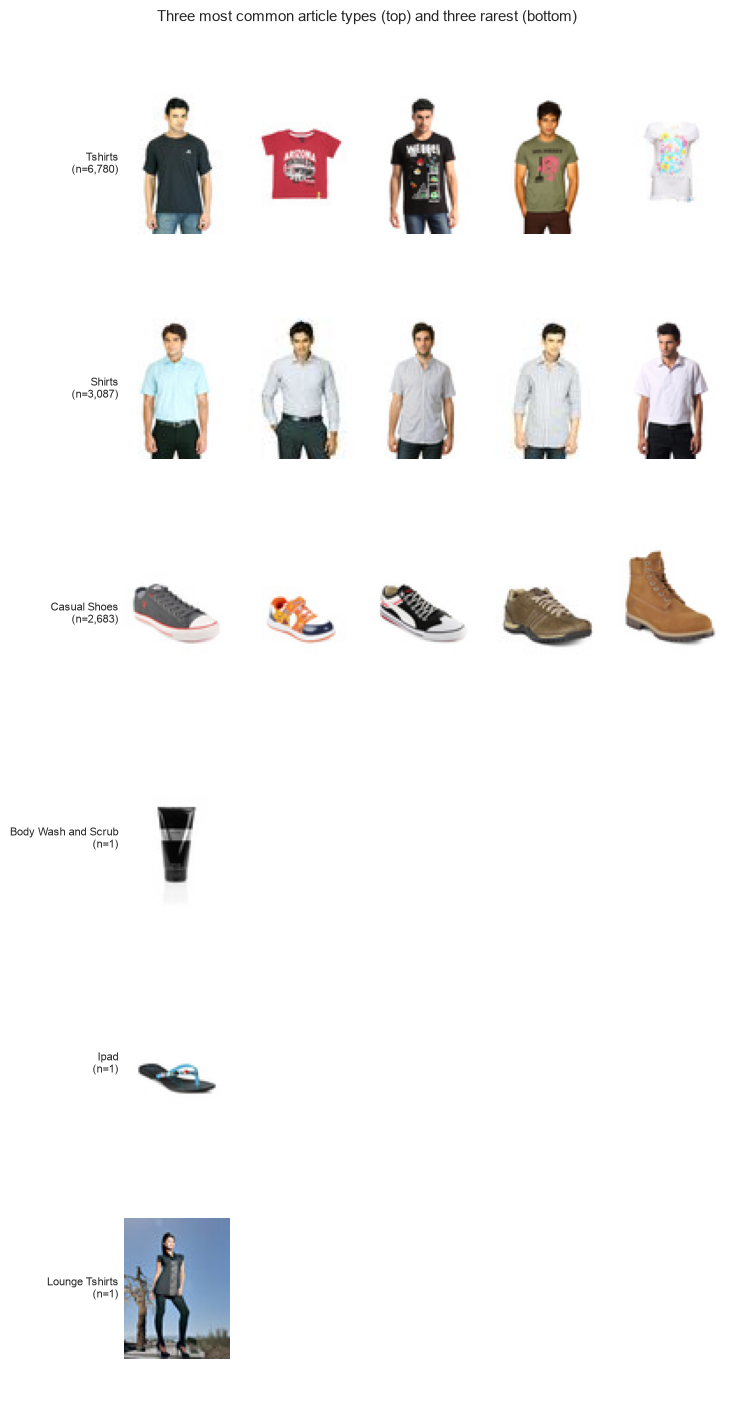

In [21]:
# The head and the tail of the articleType distribution, side by side. Offsets come from
# list position for the same reproducibility reason as the cell above.
rows, labels = [], []
for offset, label in enumerate([*article_counts.head(3).index, *article_counts.tail(3).index]):
    members = model_ready.loc[model_ready["articleType"].eq(label), ["id", "path"]]
    picked = sample_paths(members, 5, seed_offset=offset)
    rows.append([(r.path, "") for r in picked])
    labels.append(f"{label}\n(n={article_counts[label]:,})")
show_image_grid(rows, row_labels=labels,
                title="Three most common article types (top) and three rarest (bottom)")

#### Why the Tail Is Kept

`articleType` ranges from 6,780 to 1 image per class (6,780:1): 32 classes have fewer than 10 images, 21 have fewer than 5, and 6 are singletons. Seven classes cover 50% of images, 21 cover 80%, and 33 cover 90%.

`usage` has only 8 labels but also spans 29,636:1 because one class is a singleton. A singleton cannot be both trainable and evaluable in a hold-out split.

All classes and rows are retained. Rare classes are not merged or oversampled before splitting; macro metrics, class weighting, and post-split sampling remain task-level choices. Per-class results must be interpreted with their support counts.

The long tail is not removed because doing so would change the assignment label space and make aggregate results easier by deleting difficult cases. It instead sets expectations for validation coverage: some classes necessarily appear only in training, and many low-support classes will have high-variance per-class estimates.

### 2.3 Visual Confusability Between Classes

Class mean images are used as a pre-training diagnostic for visually similar labels.

In [22]:
article_support = target_counts["articleType"]
confusable_classes = sorted(article_support[article_support >= CONFUSABILITY_MIN_SUPPORT].index)
print(f"{len(confusable_classes)} of {len(article_support)} article types have "
      f">= {CONFUSABILITY_MIN_SUPPORT} images and get a mean image.")

mean_sums = {label: np.zeros((MEAN_IMAGE_SIZE[1], MEAN_IMAGE_SIZE[0], 3), dtype=np.float64)
             for label in confusable_classes}
mean_counts = Counter()
for row in model_ready.loc[model_ready["articleType"].isin(confusable_classes),
                           ["path", "articleType"]].itertuples(index=False):
    with Image.open(row.path) as image:
        pixels = np.asarray(
            ImageOps.fit(ImageOps.exif_transpose(image).convert("RGB"), MEAN_IMAGE_SIZE),
            dtype=np.float32,
        )
    mean_sums[row.articleType] += pixels
    mean_counts[row.articleType] += 1

class_mean_images = {label: mean_sums[label] / mean_counts[label] for label in confusable_classes}

70 of 124 article types have >= 30 images and get a mean image.


In [23]:
# Centre each mean image before normalising so overall brightness does not dominate similarity.
mean_matrix = np.stack([class_mean_images[label].reshape(-1) for label in confusable_classes])
mean_matrix = mean_matrix - mean_matrix.mean(axis=1, keepdims=True)
mean_matrix /= np.linalg.norm(mean_matrix, axis=1, keepdims=True)
mean_similarity = mean_matrix @ mean_matrix.T

# The product family each article type belongs to, used to flag cross-family confusion.
family_of = (
    model_ready.dropna(subset=["articleType", "subCategory"])
    .groupby("articleType")["subCategory"]
    .agg(lambda s: s.value_counts().index[0])
)

pairs = []
for a in range(len(confusable_classes)):
    for b in range(a + 1, len(confusable_classes)):
        left, right = confusable_classes[a], confusable_classes[b]
        pairs.append({
            "articleType A": left,
            "articleType B": right,
            "similarity": mean_similarity[a, b],
            "family A": family_of.get(left, "unknown"),
            "family B": family_of.get(right, "unknown"),
            "different_product_family": family_of.get(left) != family_of.get(right),
            "support A": int(mean_counts[left]),
            "support B": int(mean_counts[right]),
        })
confusable_pairs = pd.DataFrame(pairs).sort_values("similarity", ascending=False).reset_index(drop=True)

print("Most similar pairs overall:")
display(confusable_pairs.head(10).style.format({"similarity": "{:.3f}"}))

cross_family = confusable_pairs.loc[confusable_pairs["different_product_family"]]
print("Most similar pairs from DIFFERENT product families - genuinely different objects "
      "that the catalogue photographs alike:")
display(cross_family.head(10).style.format({"similarity": "{:.3f}"}))

# Printed as one line so the written interpretation below can name them without a screenshot
print("Leading cross-family pairs:", "; ".join(
    f"{row['articleType A']} vs {row['articleType B']} ({row['similarity']:.3f})"
    for _, row in cross_family.head(3).iterrows()
))

Most similar pairs overall:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
0,Kurtis,Tunics,0.992,Topwear,Topwear,False,203,175
1,Tops,Tunics,0.989,Topwear,Topwear,False,1614,175
2,Jackets,Sweatshirts,0.989,Topwear,Topwear,False,228,280
3,Kurtas,Tunics,0.986,Topwear,Topwear,False,1556,175
4,Flats,Heels,0.985,Shoes,Shoes,False,418,1048
5,Kurtis,Tops,0.984,Topwear,Topwear,False,203,1614
6,Laptop Bag,Messenger Bag,0.983,Bags,Bags,False,79,43
7,Sweaters,Sweatshirts,0.983,Topwear,Topwear,False,276,280
8,Sandals,Sports Sandals,0.982,Sandal,Sandal,False,865,63
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90


Most similar pairs from DIFFERENT product families - genuinely different objects that the catalogue photographs alike:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90
11,Stoles,Tops,0.979,Stoles,Topwear,True,90,1614
12,Stoles,Tunics,0.978,Stoles,Topwear,True,90,175
15,Innerwear Vests,Tshirts,0.974,Innerwear,Topwear,True,242,6780
17,Kurtis,Stoles,0.972,Topwear,Stoles,True,203,90
19,Casual Shoes,Sports Sandals,0.971,Shoes,Sandal,True,2683,63
21,Casual Shoes,Sandals,0.970,Shoes,Sandal,True,2683,865
22,Leggings,Lounge Pants,0.969,Bottomwear,Loungewear and Nightwear,True,159,53
25,Messenger Bag,Wallets,0.963,Bags,Wallets,True,43,829
29,Dresses,Stoles,0.959,Dress,Stoles,True,345,90


Leading cross-family pairs: Kurtas vs Stoles (0.982); Stoles vs Tops (0.979); Stoles vs Tunics (0.978)


#### Reading the Similarity Rankings

Class means are compared by cosine similarity, excluding classes below `CONFUSABILITY_MIN_SUPPORT`. Rankings are separated into expected similarities within a product family and more informative similarities across different `subCategory` branches.

The three leading cross family pairs are printed by the cell above, and the strongest of them is shown as class means beside real examples in the cell below. Those pairs are the first candidates Task 1 should check against its confusion matrix. The image check matters because two classes can average to similar white background silhouettes through framing alone, without any item level ambiguity being present.

Cross-family pairs are the most useful candidates for qualitative error analysis because they indicate that unrelated catalogue categories can share silhouette, framing, or colour at this resolution. The visual check prevents over-interpreting a high mean similarity that is driven by the standard white background alone.

Kurtas (Topwear) vs Stoles (Stoles) - cosine similarity 0.982


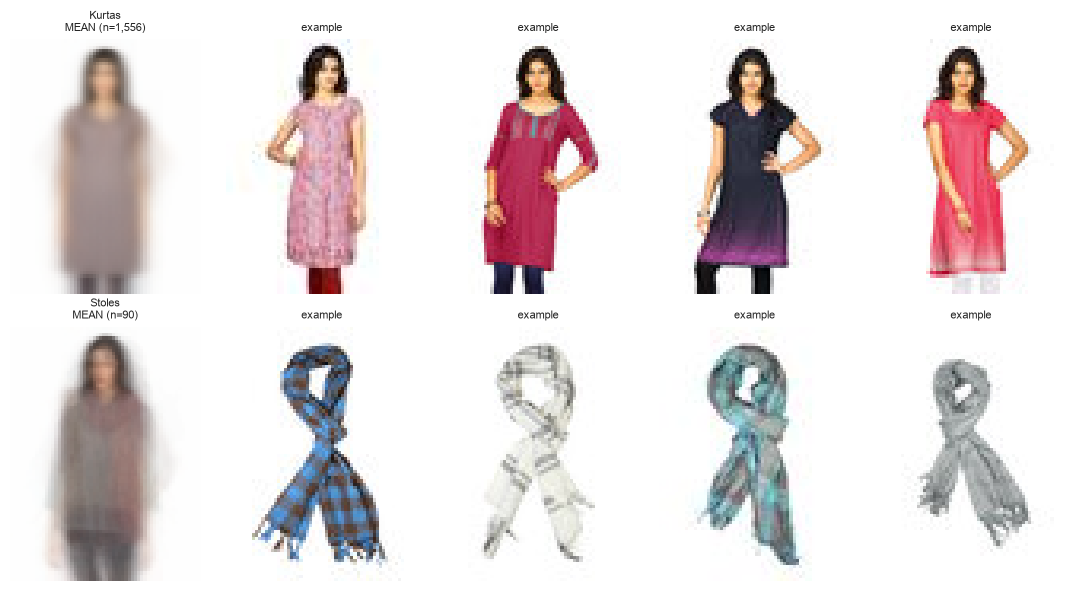

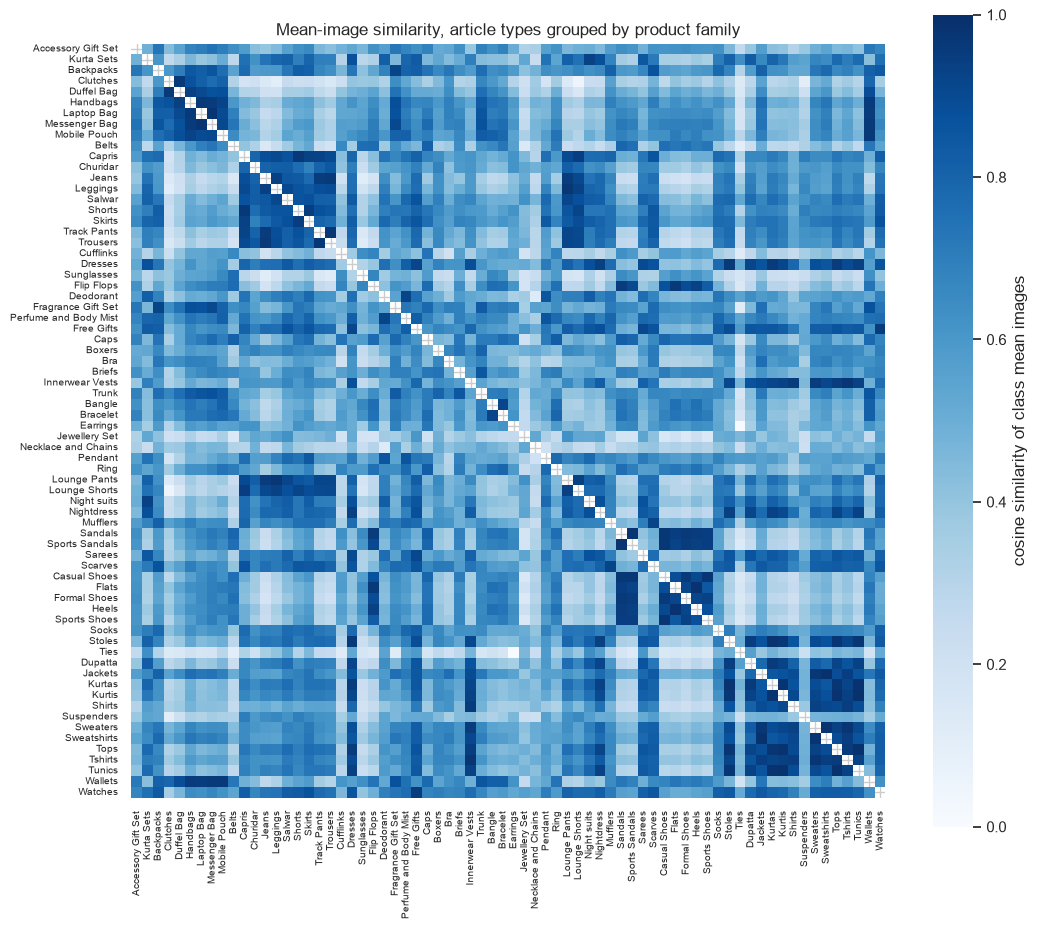

In [24]:
# Show the worst cross-family pair concretely: class means, then real examples of each.
assert len(cross_family), "No cross-family pairs; lower CONFUSABILITY_MIN_SUPPORT."
worst = cross_family.iloc[0]
pair_labels = [worst["articleType A"], worst["articleType B"]]
print(f"{pair_labels[0]} ({worst['family A']}) vs {pair_labels[1]} ({worst['family B']}) "
      f"- cosine similarity {worst['similarity']:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(11, 6))
for row_index, label in enumerate(pair_labels):
    axes[row_index, 0].imshow(class_mean_images[label].astype(np.uint8))
    axes[row_index, 0].set_title(f"{label}\nMEAN (n={mean_counts[label]:,})", fontsize=8)
    examples = model_ready.loc[model_ready["articleType"].eq(label), "path"].head(4)
    for column, example_path in enumerate(examples, start=1):
        with Image.open(example_path) as image:
            axes[row_index, column].imshow(ImageOps.exif_transpose(image).convert("RGB"))
        axes[row_index, column].set_title("example", fontsize=8)
    for ax in axes[row_index]:
        ax.axis("off")
plt.tight_layout(); plt.show()

# Similarity structure across the whole label space, grouped so families form visible blocks.
heatmap_order = sorted(confusable_classes, key=lambda label: (family_of.get(label, "unknown"), label))
position = {label: index for index, label in enumerate(confusable_classes)}
ordered = mean_similarity[np.ix_([position[l] for l in heatmap_order],
                                 [position[l] for l in heatmap_order])].copy()
np.fill_diagonal(ordered, np.nan)

fig, ax = plt.subplots(figsize=(11, 9.5))
sns.heatmap(ordered, xticklabels=heatmap_order, yticklabels=heatmap_order,
            cmap="Blues", vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "cosine similarity of class mean images"})
ax.set_title("Mean-image similarity, article types grouped by product family")
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

These are hypotheses, not model results. Task 1 should compare the ranked pairs with its confusion matrix: agreement supports a visual explanation, while disagreement points to label noise, imbalance, or optimisation instead.

### 2.4 Gender and Usage as One Target or Two

Gender and usage can be modelled as two heads or as one combined target; association and joint-label support determine the choice.

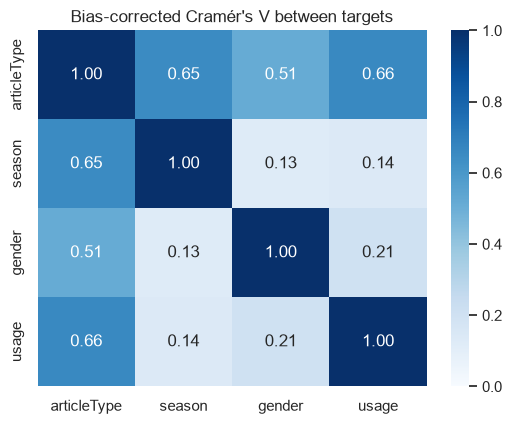

,value
possible combinations,40.0
observed combinations,24.0
combinations below 10 images,6.0
singleton combinations,3.0
largest/smallest ratio,15686.0


In [25]:
def corrected_cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.empty or min(table.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(k_corr - 1, r_corr - 1)
    return math.sqrt(phi2_corr / denominator) if denominator > 0 else np.nan


association = pd.DataFrame(index=TARGETS, columns=TARGETS, dtype=float)
for left in TARGETS:
    for right in TARGETS:
        pair = model_ready[[left, right]].dropna()
        association.loc[left, right] = (
            1.0 if left == right else corrected_cramers_v(pair[left], pair[right])
        )

fig, ax = plt.subplots(figsize=(5.5, 4.4))
sns.heatmap(association, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Bias-corrected Cramér's V between targets")
plt.tight_layout(); plt.show()

combination_counts = (
    model_ready.dropna(subset=["gender", "usage"])
    .assign(gender_usage=lambda d: d["gender"].astype(str) + " | " + d["usage"].astype(str))
    ["gender_usage"].value_counts()
)
display(pd.Series({
    "possible combinations": model_ready["gender"].nunique() * model_ready["usage"].nunique(),
    "observed combinations": len(combination_counts),
    "combinations below 10 images": int((combination_counts < 10).sum()),
    "singleton combinations": int((combination_counts == 1).sum()),
    "largest/smallest ratio": combination_counts.max() / combination_counts.min(),
}, name="value").to_frame())

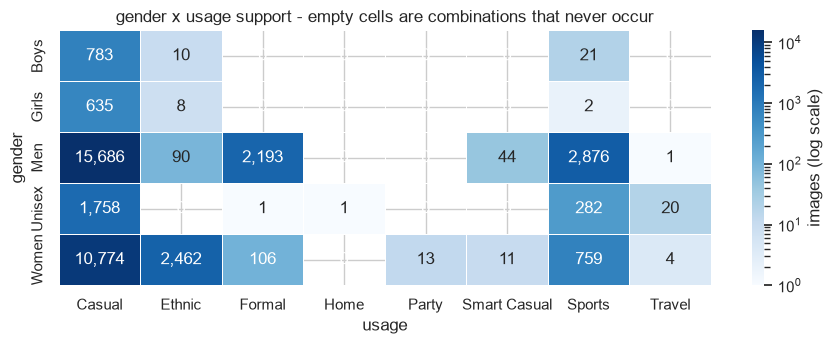

In [26]:
combination_matrix = pd.crosstab(model_ready["gender"], model_ready["usage"])
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(combination_matrix, annot=True, fmt=",d", cmap="Blues",
            norm=LogNorm(vmin=1, vmax=max(combination_matrix.to_numpy().max(), 2)),
            linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"label": "images (log scale)"})
ax.set_title("gender x usage support - empty cells are combinations that never occur")
plt.tight_layout(); plt.show()

#### Why Two Heads Rather Than One Target

Gender and usage are related but not redundant. The 5 × 8 joint space permits 40 combinations, but only 24 occur; 6 have fewer than 10 images and 3 are singletons.

Two heads are used instead of a joint label. Each head keeps every row with its own label, while the other loss is masked when missing. This avoids a sparse 24-class target and preserves the 72 rows with gender but no usage.

This choice also preserves a clear evaluation contract: gender and usage can be scored independently on every row for which that label is known. A joint target would convert missingness into an artificial class-availability problem and obscure whether errors arise from gender, usage, or their combination.

### 2.5 Metadata Leakage and the Inference Constraint

Metadata is evaluated for leakage and deployment compatibility, not merely predictive strength.

In [27]:
# What the submission template actually supplies. The constraint argued below rests on
# this file's columns, so they are read rather than quoted from the assignment brief.
prediction_columns = pd.read_csv(PREDICTION_TEMPLATE, nrows=0).columns.tolist()
print("styles_prediction.csv columns:", prediction_columns)
print("Metadata columns it does not supply:",
      sorted(set(metadata_df.columns) - set(prediction_columns)))

# How much of each target is already spelled out in the product name?
# Crude substring test (singular stem, case-insensitive) - it under-counts rather than over-counts.
leak_rows = []
for target in TARGETS:
    frame = model_ready.dropna(subset=["productDisplayName", target])
    contains = frame.apply(
        lambda row: str(row[target]).rstrip("s").lower() in row["productDisplayName"].lower(),
        axis=1,
    )
    leak_rows.append({
        "Target": target,
        "Rows with a product name": len(frame),
        "Label appears in the name": int(contains.sum()),
        "Share %": contains.mean() * 100,
    })
display(pd.DataFrame(leak_rows).style.format({"Share %": "{:.1f}%"}))

print("Example product names:")
for name in model_ready["productDisplayName"].dropna().head(5):
    print("  ", name)

styles_prediction.csv columns: ['id', 'gender', 'articleType', 'season', 'usage']
Metadata columns it does not supply: ['baseColour', 'masterCategory', 'productDisplayName', 'subCategory', 'year']


,Target,Rows with a product name,Label appears in the name,Share %
0,articleType,38605,24276,62.9%
1,season,38585,25,0.1%
2,gender,38605,36677,95.0%
3,usage,38538,4103,10.6%


Example product names:
   Nike Sahara Team India Fanwear Round Neck Jersey
   Nike Men Blue T20 Indian Cricket Jersey
   Nike Mean Team India Cricket Jersey
   Puma Deck Navy Blue Backpack
   Puma Big Cat Backpack Black


#### Why No Metadata Column Becomes a Feature

The submission template read above provides only `id` and the four targets. It does not include `masterCategory`, `subCategory`, `baseColour`, `year`, or `productDisplayName`. These fields are excluded from model inputs even though `productDisplayName` directly exposes gender for 95.0% of rows and article type for 62.9%.

The metadata remains in `model_ready` for diagnostics, including the product-family analysis in §2.3. Parent categories may support auxiliary supervision during training, but inference must still depend only on the image.

This is an inference-time constraint rather than a claim that metadata is uninformative. Using text or category fields directly would inflate validation metrics while producing a model that cannot run on the provided prediction file. The retained columns are consequently evidential and diagnostic, not model features.

## 3. Preprocessing Decisions

### 3.1 Image Geometry and the Common Transform

Image geometry is measured before selecting the common tensor transform.

In [28]:
dimension_counts = (
    readable_audit.groupby(["width", "height"]).size()
    .sort_values(ascending=False).rename("images")
)
mode_counts = readable_audit["mode"].value_counts().rename("images")

display(readable_audit[["file_bytes", "width", "height", "aspect_ratio"]].describe().T)
display(dimension_counts.head(10).to_frame())
display(mode_counts.to_frame())
print("Formats:", readable_audit["format"].value_counts().to_dict())
print(f"Grayscale images: {int(readable_audit['is_grayscale'].sum()):,} "
      f"({readable_audit['is_grayscale'].mean() * 100:.2f}%)")
print(f"Median aspect ratio (w/h): {readable_audit['aspect_ratio'].median():.3f}")

,count,mean,std,min,25%,50%,75%,max
file_bytes,38612.0,12480.446364,10059.295638,481.0000,2170.00,13831.00,20364.00,110353.0
width,38612.0,59.998550,0.100749,53.0000,60.00,60.00,60.00,60.0
height,38612.0,79.997022,0.230907,60.0000,80.00,80.00,80.00,80.0
aspect_ratio,38612.0,0.750018,0.003135,0.6625,0.75,0.75,0.75,1.0


images
width height        
60    80       38595
53    80           8
60    60           5
      77           2
      76           1
      75           1

,images
mode,
RGB,38269
L,343


Formats: {'JPEG': 38612}
Grayscale images: 343 (0.89%)
Median aspect ratio (w/h): 0.750


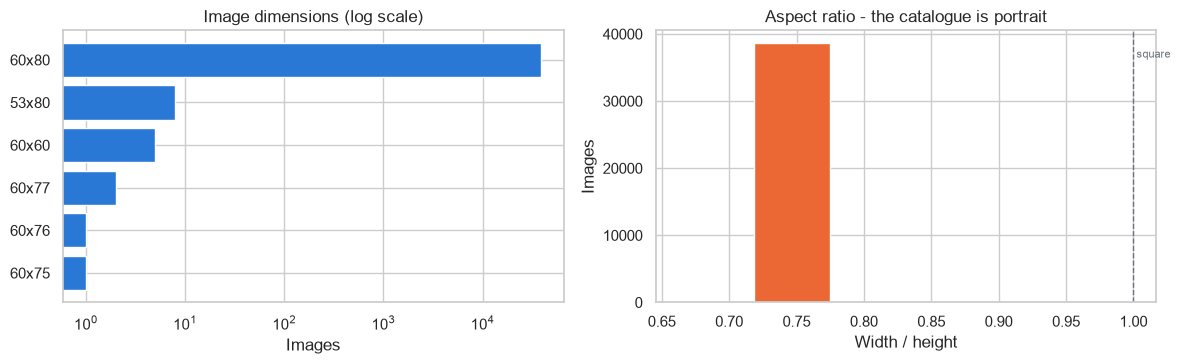

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
top_dimensions = dimension_counts.head(8).sort_values()
axes[0].barh([f"{int(w)}x{int(h)}" for w, h in top_dimensions.index], top_dimensions.values,
             color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set(title="Image dimensions (log scale)", xlabel="Images")
axes[1].hist(readable_audit["aspect_ratio"],
             bins=min(30, max(5, readable_audit["aspect_ratio"].nunique())),
             color=PALETTE[1], edgecolor="white")
axes[1].axvline(1.0, color=MUTED, ls="--", lw=1)
axes[1].text(1.0, axes[1].get_ylim()[1] * 0.9, " square", fontsize=8, color=MUTED)
axes[1].set(title="Aspect ratio - the catalogue is portrait", xlabel="Width / height", ylabel="Images")
plt.tight_layout();
plt.show();

#### Why Padding Rather Than Cropping

38,595 of 38,612 images are exactly 60×80; only 17 use other size pairs, 343 (0.89%) are grayscale, and the median aspect ratio is 0.75.

`standardize_image()` converts to RGB, preserves the portrait aspect ratio, and pads to the catalogue's modal size. This avoids cropping and distortion while leaving almost all images unresampled. Upscaling to 224×224 is an optional validation experiment, not the default.

Normalisation constants are fitted only on training rows and must be recomputed for each target size, because white padding changes the RGB distribution.

Padding is preferred to centre-cropping because the portrait shape can contain class cues at both the top and bottom of a product, such as collars, hems, or shoe heels. Stretching would preserve all content but distort proportions that may differentiate similar article types. The modal native size keeps the intervention minimal: only the small set of atypical files is resampled.

The transform is deterministic and deliberately separated from augmentation. This keeps experiments interpretable: a change in architecture or training augmentation does not silently alter the handling of grayscale files, aspect ratio, or source resolution. The verification cells exercise every observed image size and colour mode before task-specific models reuse the transform.

Native size 60x80 covers 38,595 images (99.96%); 17 images need resizing.
Transform verified at (60, 80) on 7 images covering every observed size and colour mode.


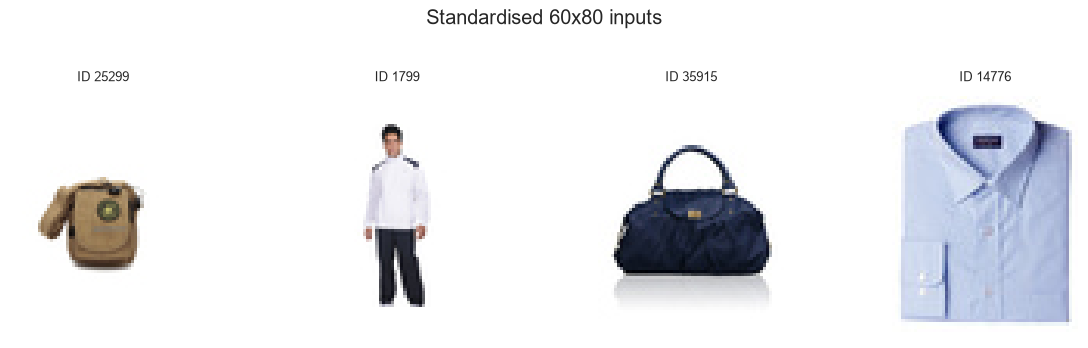

In [30]:
# Default: the catalogue's own modal size, so most images pass through unresized.
# Experiment later by overriding this one constant, e.g. IMAGE_TARGET_SIZE = (224, 224).
NATIVE_IMAGE_SIZE = tuple(int(v) for v in dimension_counts.index[0])  # (width, height)
IMAGE_TARGET_SIZE = NATIVE_IMAGE_SIZE

native_share = dimension_counts.iloc[0] / dimension_counts.sum() * 100
print(f"Native size {NATIVE_IMAGE_SIZE[0]}x{NATIVE_IMAGE_SIZE[1]} covers "
      f"{dimension_counts.iloc[0]:,} images ({native_share:.2f}%); "
      f"{int(dimension_counts.iloc[1:].sum()):,} images need resizing.")


def standardize_image(image, target_size=None):
    """Deterministic Task 1-4 input transform. Augmentation goes after this, normalisation last.

    target_size defaults to the module-level IMAGE_TARGET_SIZE at call time rather than at
    definition time, so overriding that constant takes effect without re-running this cell.
    """
    target_size = tuple(target_size or IMAGE_TARGET_SIZE)
    image = ImageOps.exif_transpose(image).convert("RGB")
    if image.size == target_size:
        return image  # already the target size: no resampling at all
    return ImageOps.pad(
        image, target_size, method=Image.Resampling.BILINEAR,
        color=IMAGE_PAD_RGB, centering=(0.5, 0.5),
    )


# Verify the transform against every observed source dimension and one grayscale file.
check_ids = readable_audit.groupby(["width", "height"], sort=True)["id"].first().tolist()
grayscale_ids = readable_audit.loc[readable_audit["is_grayscale"], "id"]
if len(grayscale_ids):
    check_ids.append(int(grayscale_ids.iloc[0]))

for check_id in dict.fromkeys(map(int, check_ids)):
    with Image.open(path_by_id.loc[check_id]) as image:
        standardized = standardize_image(image)
    assert standardized.size == IMAGE_TARGET_SIZE and standardized.mode == "RGB"
print(f"Transform verified at {IMAGE_TARGET_SIZE} on {len(set(check_ids))} images "
      f"covering every observed size and colour mode.")

sample_ids = list(dict.fromkeys(map(int, check_ids)))[:4]
fig, axes = plt.subplots(1, len(sample_ids), figsize=(3 * len(sample_ids), 3.4))
for ax, sample_id in zip(np.atleast_1d(axes), sample_ids):
    with Image.open(path_by_id.loc[sample_id]) as image:
        ax.imshow(standardize_image(image))
    ax.set_title(f"ID {sample_id}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Standardised {IMAGE_TARGET_SIZE[0]}x{IMAGE_TARGET_SIZE[1]} inputs", y=1.02)
plt.tight_layout(); plt.show()

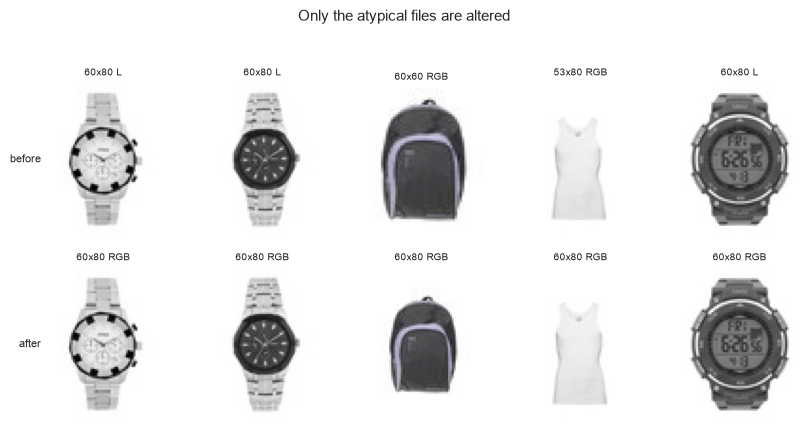

In [31]:
# Before and after, on the files the transform actually has to change.
awkward = pd.concat([odd_sized, grayscale_files]).drop_duplicates("id")
before_after = sample_paths(awkward, 5, seed_offset=4)
if before_after:
    fig, axes = plt.subplots(2, len(before_after), figsize=(1.7 * len(before_after), 4.2), squeeze=False)
    for column, record in enumerate(before_after):
        with Image.open(record.path) as image:
            original = ImageOps.exif_transpose(image).convert("RGB")
            transformed = standardize_image(image)
        for row_index, (picture, caption) in enumerate(
            [(original, f"{original.size[0]}x{original.size[1]} {record.mode}"),
             (transformed, f"{transformed.size[0]}x{transformed.size[1]} RGB")]
        ):
            ax = axes[row_index][column]
            ax.imshow(picture)
            ax.set_title(caption, fontsize=7)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
    axes[0][0].set_ylabel("before", fontsize=8, rotation=0, ha="right", va="center")
    axes[1][0].set_ylabel("after", fontsize=8, rotation=0, ha="right", va="center")
    fig.suptitle("Only the atypical files are altered", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

### 3.2 Duplicate Handling

#### 3.2.1 Collapsing Consistent Duplicate Groups

In 636 byte-identical groups, 616 have no conflicting target values (615 are complete; one pair has `usage` missing in both rows). They are repeated image-label pairs, so one deterministic representative (the smallest `id`) is retained per group.

In [32]:
# Collapse only duplicate groups whose available target labels do not conflict.
# Conflicting groups remain unchanged for the task-specific decisions below.
consistent_label_hashes = group_labels.index[group_labels.le(1).all(axis=1)]
shared_missing_label_hashes = consistent_label_hashes[
    group_labels.loc[consistent_label_hashes].eq(0).any(axis=1)
]
consistent_group_sizes = (
    model_ready.loc[model_ready["group_id"].isin(consistent_label_hashes)]
    .groupby("group_id")
    .size()
)

consistent_duplicate_summary = pd.DataFrame([
    ["Groups with no label conflict", len(consistent_label_hashes)],
    ["Consistent groups with a shared missing label", len(shared_missing_label_hashes)],
    ["Images in groups with no label conflict", int(consistent_group_sizes.sum())],
], columns=["Measure", "Count"])

display(consistent_duplicate_summary)

,Measure,Count
0,Groups with no label conflict,616
1,Consistent groups with a shared missing label,1
2,Images in groups with no label conflict,1358


In [33]:
# One representative per consistent group, taken as the smallest id so the retained record
# is fixed by the data rather than by row order.
representative_ids = set(
    model_ready.loc[model_ready["group_id"].isin(consistent_label_hashes), ["group_id", "id"]]
    .sort_values(["group_id", "id"])
    .drop_duplicates("group_id", keep="first")["id"]
)

deduplicated_model_ready = model_ready.loc[
    ~model_ready["group_id"].isin(consistent_label_hashes)
    | model_ready["id"].isin(representative_ids)
].copy().reset_index(drop=True)

print("Rows before collapsing:", f"{len(model_ready):,}")
print("Consistent groups collapsed:", f"{len(consistent_label_hashes):,}")
print("Rows removed:", f"{len(model_ready) - len(deduplicated_model_ready):,}")
print("Rows after collapsing:", f"{len(deduplicated_model_ready):,}")

Rows before collapsing: 38,612
Consistent groups collapsed: 616
Rows removed: 742
Rows after collapsing: 37,870


#### What Collapsing Costs

The rows removed here are repeated image and label pairs, so nothing observable is lost: every retained representative carries the same pixels and the same targets as the copies it replaces. Keeping them would let one product weight the loss several times and would let a split reward memorising training pixels. Groups with conflicting labels are untouched at this stage and are decided individually in Section 3.2.2.

#### 3.2.2 Resolving Conflicting Duplicate Labels

The 20 exact-duplicate groups whose labels still conflict are reviewed record by record through the audit table below. `model_ready` and the raw catalogue are left intact, and the documented decisions are applied once, to a single frame named `task_ready`, which is what Section 3.4 exports.

In [34]:
# Map byte-identical groups whose labels still conflict after clean duplicates
# have been collapsed. Conflict groups are intentionally unchanged in the base.
conflict_flags = group_labels.gt(1).rename(
    columns={target: f"{target}_conflict" for target in TARGETS}
)

conflicting_image_metadata = (
    deduplicated_model_ready.loc[
        deduplicated_model_ready["group_id"].isin(conflicting_hashes),
        ["group_id", "id", "filename", "productDisplayName", *TARGETS],
    ]
    .rename(columns={"group_id": "sha256"})
    .merge(
        conflict_flags,
        left_on="sha256",
        right_index=True,
        how="left",
        validate="many_to_one",
    )
)

conflicting_image_metadata["conflicting_fields"] = (
    conflicting_image_metadata[conflict_flags.columns]
    .apply(
        lambda row: ", ".join(
            column.removesuffix("_conflict")
            for column, is_conflict in row.items()
            if is_conflict
        ),
        axis=1,
    )
)

conflicting_image_metadata["duplicate_group_size"] = (
    conflicting_image_metadata.groupby("sha256")["id"].transform("size")
)

conflicting_image_metadata = (
    conflicting_image_metadata[
        [
            "sha256",
            "duplicate_group_size",
            "conflicting_fields",
            "id",
            "filename",
            "productDisplayName",
            *TARGETS,
        ]
    ]
    .sort_values(["sha256", "id"])
    .reset_index(drop=True)
)

display(conflicting_image_metadata)

,sha256,duplicate_group_size,conflicting_fields,id,filename,productDisplayName,articleType,season,gender,usage
0,101c50e6458d7ef48893fa3d7b464167589d23e0bdef6e9335351d582df6e268,2,gender,39107,39107.jpg,ADIDAS Mumbai Indians Boys Blue Match Cap,Caps,Summer,Boys,Sports
1,101c50e6458d7ef48893fa3d7b464167589d23e0bdef6e9335351d582df6e268,2,gender,39108,39108.jpg,ADIDAS Mumbai Indians Girls Blue Match Cap,Caps,Summer,Girls,Sports
2,10ee6d9aaa238c17a8eb0d3f21bd1e83afde3f9d48f8c7081d4e83b0aeb633fc,2,season,7158,7158.jpg,Scullers Men Green Check Shirt,Shirts,Fall,Men,Casual
3,10ee6d9aaa238c17a8eb0d3f21bd1e83afde3f9d48f8c7081d4e83b0aeb633fc,2,season,8786,8786.jpg,Scullers Men Blue & Green Check Shirt,Shirts,Summer,Men,Casual
4,1469f29721659fff4624704c271b1bf88f7e4de11ada94113c6b9cddfd46be2f,2,gender,36762,36762.jpg,Maxima Men White Dial Watch,Watches,Winter,Men,Casual
5,1469f29721659fff4624704c271b1bf88f7e4de11ada94113c6b9cddfd46be2f,2,gender,36771,36771.jpg,Maxima Women White Dial Watch,Watches,Winter,Women,Casual
6,261a589e0ad8167a6953a5a7849a4657a3523a982304ea21c989b107aa347f02,2,season,11346,11346.jpg,Lee Men Blue Zed Fit Jeans,Jeans,Spring,Men,Casual
7,261a589e0ad8167a6953a5a7849a4657a3523a982304ea21c989b107aa347f02,2,season,11347,11347.jpg,Lee Men Elvira Rinse Blue Chicago Fit Jeans,Jeans,Summer,Men,Casual
8,29b6d48fdf58b0b5917cc3c6338baa6fe4a72c560d1a309bd288049bb800c823,2,gender,13306,13306.jpg,Gini and Jony Kids Solid Black Trousers,Trousers,Fall,Boys,Casual
9,29b6d48fdf58b0b5917cc3c6338baa6fe4a72c560d1a309bd288049bb800c823,2,gender,13307,13307.jpg,Gini and Jony Kids Solid Black Trousers,Trousers,Fall,Men,Casual


**What was discovered?**

The audit table contains 20 exact-duplicate groups with at least one conflicting target.

- **Article type (7 groups):** **4** conflicts include Sunglasses/Free Gifts, Shorts/Capris, Tops/Tshirts, Free Gifts/Sarees, and the **3** multi-label groups.
- **Season (8 groups):** **5** season-only groups and **3** multi-label groups conflict. Season is weakly visible, so `productDisplayName` is supporting evidence; socks `18580`/`18592` remain ambiguous.
- **Gender (7 groups):** **7** conflicts span `Boys`/`Girls`, `Men`/`Women`, `Boys`/`Men`, and `Men`/`Unisex`; names and visual review provide a defensible retained label.
- **Usage (3 groups):** **1** Casual/Formal pair (`27559`/`43410`) and two multi-label groups conflict.
- **Multiple labels (3 groups):** `21810`/`23810`, `1165`/`5062`, and `12345`/`12346` disagree on article type plus one or more additional targets.

**Decision**

Three of the twenty groups support no defensible label for one target, but their other three targets are sound. Removing the record entirely would impose one task's label gap on the other three, which Section 3.3 rejects. One representative is therefore kept with only the undecidable target set to `NaN`. The remaining exclusions are byte-identical copies of a record retained with a defensible label, so removing them costs nothing observable.

- **Article type:** retain `28345` as `Sunglasses`, `33259` as `Shorts`, and `51101` as `Sarees`; drop the duplicate copies `28347`, `39336`, `51073`. Keep `4898` with `articleType` set to `NaN` and drop its copy `4899`, because the shared name does not distinguish `Tops` from `Tshirts`.
- **Season:** retain `7158` as `Fall`, `11347` and `37151` as `Summer`, and `2640` as `Winter`; drop their duplicate copies. Keep socks `18580` with `season` set to `NaN` and drop `18592`; the item carries no seasonal cue.
- **Gender:** retain `39107` and `36762` as `Unisex`, `13306` and `8325` as `Boys`, `28167` and `30566` as `Men`, and `23793` as `Unisex`; drop the duplicate copies.
- **Usage:** keep `27559` with `usage` set to `NaN` and drop `43410`, because the shared product name does not distinguish `Casual` from `Formal`.
- **Multiple labels:** retain `23810` as `Casual Shoes`, `Fall`, and `Casual`; exclude `21810`. Exclude `1165`/`5062` and `12345`/`12346` outright, since two or more targets conflict and no representative is usable for any task.

In [35]:
# The decisions recorded above, applied in one pass. Every record named in the audit table
# appears exactly once below, grouped under the target that drove the decision, so the
# table and the code can be read against each other line by line.

# Byte-identical copies of a record retained with a defensible label. Removed outright,
# because keeping them would repeat the same pixels under a contradictory label.
REDUNDANT_DUPLICATE_IDS = {
    28347, 39336, 51073,                                    # articleType
    8786, 11346, 19110, 2638,                               # season
    39108, 36771, 13307, 8273, 30568, 28186, 28188, 24301,  # gender
}

# No member of the group supports a defensible label for the target named, but the other
# three targets are sound. One representative is kept and only that target is set to NaN,
# so the record stays available to the tasks it is still valid for (Section 3.3).
UNDECIDABLE_TARGET_GROUPS = {
    "articleType": {"keep": 4898,  "drop": 4899},   # Tops vs Tshirts
    "season":      {"keep": 18580, "drop": 18592},  # socks, no seasonal cue
    "usage":       {"keep": 27559, "drop": 43410},  # Casual vs Formal
}

# Two or more targets conflict, so no representative is usable for any task.
MULTI_TARGET_CONFLICT_IDS = {21810, 1165, 5062, 12345, 12346}

# Retained with a corrected label rather than excluded
RELABELLED_UNISEX_IDS = [39107, 36762]

EXCLUDED_IDS = (
    REDUNDANT_DUPLICATE_IDS
    | MULTI_TARGET_CONFLICT_IDS
    | {group["drop"] for group in UNDECIDABLE_TARGET_GROUPS.values()}
)

# Fail loudly rather than silently skipping a decision whose record has already gone
decision_ids = (
    EXCLUDED_IDS
    | set(RELABELLED_UNISEX_IDS)
    | {group["keep"] for group in UNDECIDABLE_TARGET_GROUPS.values()}
)
present_ids = set(deduplicated_model_ready["id"])
missing_decisions = sorted(decision_ids - present_ids)
if missing_decisions:
    raise ValueError(f"Decision records not present in the frame: {missing_decisions}")

task_ready = deduplicated_model_ready.loc[
    ~deduplicated_model_ready["id"].isin(EXCLUDED_IDS)
].copy().reset_index(drop=True)

task_ready.loc[task_ready["id"].isin(RELABELLED_UNISEX_IDS), "gender"] = "Unisex"

for target, group in UNDECIDABLE_TARGET_GROUPS.items():
    task_ready.loc[task_ready["id"].eq(group["keep"]), target] = np.nan

# The claim in 3.2.2 is that no contradictory supervision survives. Check it rather than
# assert it, since a decision list this long is easy to get subtly wrong.
surviving_conflicts = task_ready.groupby("group_id")[TARGETS].nunique()
assert surviving_conflicts.le(1).all().all(), \
    sorted(surviving_conflicts.index[surviving_conflicts.gt(1).any(axis=1)])

print("Rows before the conflict decisions:", f"{len(deduplicated_model_ready):,}")
print("Records excluded:", len(EXCLUDED_IDS))
print("Records kept with one target set to NaN:", len(UNDECIDABLE_TARGET_GROUPS))
print("Records relabelled to Unisex:", len(RELABELLED_UNISEX_IDS))
print("Rows after the conflict decisions:", f"{len(task_ready):,}")
print("Groups still holding conflicting labels:",
      int(surviving_conflicts.gt(1).any(axis=1).sum()))

Rows before the conflict decisions: 37,870
Records excluded: 23
Records kept with one target set to NaN: 3
Records relabelled to Unisex: 2
Rows after the conflict decisions: 37,847
Groups still holding conflicting labels: 0


### 3.3 Remaining Missing Labels

Section 1.3 measured missingness per target rather than globally: `season` is absent on 20 rows, `usage` on 72, `baseColour` on 14, and `productDisplayName` on 7.

A single complete case filter over every column is rejected on two grounds, and both are consequences of findings already recorded.

- It would delete rows for `baseColour` and `productDisplayName`, which Section 2.5 excluded from model inputs because `styles_prediction.csv` does not supply them. Those rows would be discarded over fields no model reads.
- It would impose Task 2 and Task 3b label gaps on Task 1 and Task 3a, whose labels are complete. Both tasks would lose examples that are entirely valid for them.

Every row therefore survives with its missing labels intact, and each task section filters on its own label column when it builds its split. The counts below are the denominators those sections must reproduce.

In [36]:
# No global complete case filter. These are the per task denominators after the
# duplicate decisions in Section 3.2, and each task section must arrive at the same figure.
task_rows = pd.DataFrame(
    [[target,
      int(task_ready[target].notna().sum()),
      int(task_ready[target].isna().sum())]
     for target in TARGETS],
    columns=["Target", "Rows with a label", "Rows without a label"],
)

display(task_rows)

print("Rows retained for export:", f"{len(task_ready):,}")
print("Rows that would survive a global dropna:",
      f"{int(task_ready.notna().all(axis=1).sum()):,}")

,Target,Rows with a label,Rows without a label
0,articleType,37846,1
1,season,37826,21
2,gender,37847,0
3,usage,37775,72


Rows retained for export: 37,847
Rows that would survive a global dropna: 37,745


#### The Cost of a Global Filter

The final column of the table is the cost a global filter would carry. Rows lost to it are lost from tasks whose own label is present, which is why the filter is not applied. The difference between the two printed totals is the number of rows a complete case rule would remove for the sake of a column no model reads.

### 3.4 Persisting the Audited Manifest

What this notebook produces is an audit result, not a new image set. Every transformation defined above is deterministic and stateless, so the pixels a task notebook needs are reproducible from the raw files by calling `standardize_image()` at load time, which a data loader does anyway in order to apply augmentation.

Only the manifest is written: the cleaned metadata, the surviving row set after the Section 3.2 decisions, the filename each row loads, and the `group_id` each split must respect. Normalisation and augmentation remain task specific and are fitted after each task splits.

In [37]:
# What is persisted is the audit result, not the pixels. Every image transformation in
# this notebook is deterministic and stateless, so a task notebook reproduces it by
# calling standardize_image() at load time. Writing 38,000 re-encoded JPEGs would
# duplicate the dataset, add a second generation of compression loss to images the
# transform never changes, and go stale the moment IMAGE_TARGET_SIZE is overridden.

# filename rather than path, so the manifest does not depend on this machine.
# group_id is kept because every task splits on it.
export_rows = task_ready.drop(columns=["path"]).sort_values("id").reset_index(drop=True)

EXPORT_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
export_rows.to_csv(EXPORT_MANIFEST, index=False, encoding="utf-8")

# Guards against the failures that would otherwise surface inside a task notebook
reloaded = pd.read_csv(EXPORT_MANIFEST)
source_files = {path.name for path in TRAIN_IMAGE_DIR.iterdir() if path.is_file()}

assert len(reloaded) == len(export_rows)
assert reloaded["id"].is_unique
assert "group_id" in reloaded.columns
assert set(reloaded["filename"]) <= source_files

print("Manifest written:", EXPORT_MANIFEST.resolve())
print("Rows:", f"{len(reloaded):,}")
print("Columns:", list(reloaded.columns))
print("Size on disk:", f"{EXPORT_MANIFEST.stat().st_size / 1024:.0f} KB")

Manifest written: D:\Machine-Learning-Assignment-2\preprocessed_datasets\train_manifest.csv
Rows: 37,847
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'filename', 'group_id']
Size on disk: 6401 KB


#### What the Guards Rule Out

The manifest is checked against the source image folder before this section ends, so a task notebook cannot fail later on a row whose file does not exist. `group_id` travels with it because Section 1.6 established that byte identical images must not land on both sides of a split. `path` does not, because it is an absolute location on the machine that ran this notebook.

The raw dataset is never modified. It is opened read only throughout, and the only file this notebook writes is the manifest.

### 3.5 Why the Split Is Not Performed Here

- The four targets have different eligible rows, different cleaned labels, different class distributions, and different rare class constraints.
- One global split may suit one target while leaving another with a poor training or validation distribution.
- A shared split would also carry a Section 3.2 exclusion into tasks for which that record is still valid.
- Each task therefore builds the split that matches its own eligible population, following the rules set out in Section 5.

### 3.6 Test Set Readiness Check

The audit in Section 1 covers the training catalogue. Tasks 1 to 3 must also produce a prediction for every row of `styles_prediction.csv`, so the same integrity questions are asked of the test images: does every id have a file, does the transform survive the sizes and colour modes present, and does any test image already appear in training.

One qualification belongs here rather than buried. This section reads the test image files, so the test set has been inspected before modelling. The inspection is defensible as a compatibility and integrity check rather than as model selection, and the boundary is stated so the reader can weigh it.

- Nothing measured here is fitted to. `standardize_image()` pads to a target size fixed in Section 3.1 from training data alone, so the test dimensions are checked only for whether the transform crashes, never for what it should do.
- No normalisation constant, threshold, or hyperparameter is derived from a test statistic.
- No test row is dropped, reweighted, or special cased. Every id receives a prediction.
- The audit writes nothing. The test files are opened read only and left byte for byte unchanged.

The duplicate overlap count is the one result that carries into the report. If test images are byte identical to training images, the reported test performance is partly a memorisation score and must be qualified as such. The count is used to caveat a number, never to change a model or to exclude a row.

In [38]:
# TEST_IMAGE_DIR comes from the path block in the third code cell; it is not redefined here.
prediction_ids = pd.read_csv(PREDICTION_TEMPLATE)["id"]

test_records = []
for path in sorted(TEST_IMAGE_DIR.iterdir()):
    if not path.is_file() or path.suffix.lower() != ".jpg":
        continue
    raw_bytes = path.read_bytes()
    with Image.open(BytesIO(raw_bytes)) as image:
        image = ImageOps.exif_transpose(image)
        test_records.append({
            "id": int(path.stem), "width": image.width, "height": image.height,
            "mode": image.mode, "sha256": hashlib.sha256(raw_bytes).hexdigest(),
        })

test_audit = pd.DataFrame(test_records)
at_native = test_audit["width"].eq(IMAGE_TARGET_SIZE[0]) & test_audit["height"].eq(IMAGE_TARGET_SIZE[1])

display(pd.DataFrame([
    ["Rows in styles_prediction.csv", len(prediction_ids)],
    ["Test image files", len(test_audit)],
    ["Prediction ids with a matching file", int(prediction_ids.isin(test_audit["id"]).sum())],
    ["Test images already at the target size", int(at_native.sum())],
    ["Grayscale test images", int(test_audit["mode"].isin({"1", "L", "I", "F"}).sum())],
    ["Test images byte identical to a training image",
     int(test_audit["sha256"].isin(set(readable_audit["sha256"])).sum())],
], columns=["Test set measure", "Count"]))

# The transform must survive every size and colour mode the test set actually contains
for check_id in test_audit.groupby(["width", "height", "mode"])["id"].first():
    with Image.open(TEST_IMAGE_DIR / f"{check_id}.jpg") as image:
        standardized = standardize_image(image)
    assert standardized.size == IMAGE_TARGET_SIZE and standardized.mode == "RGB"
print("Transform verified on every size and colour mode present in the test set.")

,Test set measure,Count
0,Rows in styles_prediction.csv,5829
1,Test image files,5829
2,Prediction ids with a matching file,5829
3,Test images already at the target size,5823
4,Grayscale test images,88
5,Test images byte identical to a training image,11


Transform verified on every size and colour mode present in the test set.


## 4. Preprocessing Decisions and Limitations

### 4.1 Decision Log

| Decision | Evidence | Section |
|---|---|---|
| Rejoin 21 spilled product names rather than repair labels | The spill sits after the last labelled column, so no target is misaligned | 1.1 |
| Exclude 5 rows with no image file | The files are absent from `images_train`, and one is the only `Suits` record | 1.4 |
| Collapse 616 consistent duplicate groups to one representative each | Same pixels and same labels, so nothing observable is lost and split leakage is prevented | 3.2.1 |
| Resolve 20 conflicting groups record by record | Product names and visual review support a single label in 17 groups; the duplicate copy is dropped | 3.2.2 |
| Keep 3 undecidable records with only the disputed target set to NaN | Their other three targets are sound, and dropping the row would impose one task's label gap on the others | 3.2.2, 3.3 |
| Retain every rare and singleton class | Removing them would change the assignment label space and make aggregate results easier by deleting the hard cases | 2.2 |
| Model gender and usage as two heads, not one joint target | Only 24 of 40 combinations occur, 6 below 10 images and 3 singletons | 2.4 |
| Exclude all metadata columns from model inputs | `styles_prediction.csv` supplies only `id` and the four targets | 2.5 |
| Pad to the modal 60x80 rather than crop or stretch | 38,595 of 38,612 images are already that size, and both alternatives lose or distort class cues | 3.1 |
| Apply no global complete case filter | It would delete rows over columns no model reads and impose one task's label gaps on another | 3.3 |
| Persist an audited manifest rather than a second copy of the images | The transform is deterministic and stateless, so re-encoding 38,000 JPEGs would duplicate the dataset, add a second generation of compression loss, and go stale whenever `IMAGE_TARGET_SIZE` changes | 3.4 |
| Defer splits, normalisation, and augmentation to the task sections | The four tasks have different eligible rows and different class structures | 3.5 |

### 4.2 Limitations

- **Duplicate detection is exact only.** SHA-256 finds byte identical files. Alternate views, colourways, and reshoots of the same product are not detected and can still cross a split. Perceptual hashing would close this and is not implemented.
- **Conflict resolution is partly judgement.** Where the product name distinguishes the labels, the retained record is defensible. Where it does not, both records are excluded, which trades a small amount of data for the certainty that no contradictory supervision reaches a model. Neither route is verifiable against ground truth, since the catalogue is the only source available.
- **One class is lost to a missing file.** `Suits` has a single record and that record has no image, so image models can observe 124 of the 125 metadata classes and can never predict the missing one.
- **Singleton and near singleton classes cannot be both trained and evaluated.** 6 `articleType` classes and 1 `usage` class hold a single image. Any per class metric for them is meaningless, and some classes will necessarily appear only in training.
- **The mean image diagnostic is a hypothesis generator.** Cosine similarity between class means at 60x80 measures average silhouette, framing, and colour. It cannot separate genuine item level ambiguity from a shared white background, and classes below 30 images are excluded from it entirely.
- **Native resolution caps the visual detail available.** The source images are 60x80. Any task section that runs at a larger tensor size is interpolating, not recovering detail, so an improvement at 224x224 should be attributed to the architecture rather than to added information.
- **No normalisation constants are computed here.** They depend on the target size and on which rows land in training, so they must be fitted inside each task section after its split and applied unchanged to validation.
- **Eleven test images are byte-identical to training images.** Section 3.6 found the overlap. It is not acted on, since no test row is dropped or reweighted, but any reported test score is to that extent a memorisation score and is qualified as such.

---

## 5. Handover to the Task Notebooks

Tasks 1 to 4 each read `preprocessed_datasets/train_manifest.csv`, written by Section 3.4, and load their images from `datasets/train/images_train/`. They do not repeat this audit. `model_ready` stays inside this notebook as the diagnostic table; the manifest is what carries the Section 3.2 decisions.

`standardize_image()` is the one piece of code a task notebook needs from here. It is deterministic and stateless, and it lives in `src/preprocessing.py` so that all four notebooks import the same definition rather than keeping four copies that could drift apart. The definition in Section 3.1 is the source; the module is a verbatim copy checked by the assertion at the end of that section.

Five rules every task section follows, each a consequence of a finding above.

1. Split on `group_id` as the grouping key, so the byte identical images found in Section 1.6 cannot land on both sides.
2. Select rows on that task's own label column rather than on a global complete case filter, for the reason recorded in Section 3.3.
3. Use an approximately 80:20 hold out split, stratified wherever class support permits. Keeping whole `group_id` values on one side means the achieved ratio will differ slightly from 80:20.
4. Keep singleton classes in training, since a class with one example cannot be both trained on and evaluated.
5. Fit normalisation constants and every other statistic on training rows only, then apply them unchanged to validation.

`IMAGE_TARGET_SIZE` is the one setting deliberately left open. The default holds images at their native 60x80, and a task section may rerun at a larger size to test whether interpolation pays for itself, provided it reports the comparison rather than only the larger result.